# Supplement Notebook: Revisions for Chapter 2

**Manuscript:** *Network-Aware Optimal Control of SEITR Epidemic Models: Limits of Mean-Field Strategies and the Role of Temporal Resolution*

This notebook collects all code-supported revisions required by reviewer feedback. It is organized section-by-section to match the revision plan and leaves the original experimental runs at $n=100$ untouched.

## Scope

| Section | Revision target | Source (reviewer) | Type |
|---|---|---|---|
| 1 | Notation consistency ($w \leftrightarrow w_1$) | R1 | Documentation |
| 2 | Figure redesign: Fig. 1 (ODE) and Fig. 5 ($K$-sweep) | R1 | Regeneration from saved data |
| 3 | Positivity and boundedness of the controlled SEITR ODE | R1 | Analytical + numerical verification |
| 4 | Disease-free and endemic equilibria, basic reproduction number $R_0$ | R1, R2 | Analytical + numerical |
| 5 | Local linear stability at DFE and EE | R1 | Numerical eigenvalue analysis |
| 6 | Bifurcation analysis (transcritical, Hopf search) | R1 | Parameter sweep; Jacobian eigenvalue tracking |
| 7 | Sensitivity analysis (forward sensitivity of $R_0$; PRCC of outcomes) | R1 | Numerical |
| 8 | Scaling experiment ($n\in\{200,500,1000\}$) | R1 | New forward-simulation runs |

## Key scope decisions

- Cross-topology extensions (BA, WS) remain deferred to the companion manuscript on topology effects. Only Erdős–Rényi networks are used here.
- No empirical COVID-19 calibration is attempted. Parameters remain the ``COVID-like'' set used in the main manuscript.
- The existing $n=100$ experimental grid is not re-executed. Figures are regenerated from saved data via improved plotting templates.
- The Hopf bifurcation analysis is included to connect conceptually with the companion neuroscience work. The structural contrast between standard SEITR and neural models (where Hopf dominates) is discussed in Section 6c.

## Conventions

- All analysis uses the controlled ODE form given in the main manuscript Eq. (3): $\dot I = \beta_2 E - (\beta_3 + \delta_I + \mu + u) I$. The baseline treatment rate $\alpha_1$ does not appear in the controlled ODE; it is retained only in the network simulator per the implementation note in the supplement (S3.3).
- The weight parameter is consistently denoted $w_1$ throughout this notebook to match the implementation (see Section 1).


## 0. Setup

Library loading, global parameters, and output directory. The parameter set is taken verbatim from the main manuscript, Table S1 of the supplement, and Figure 1 caption.

In [1]:
# Libraries -----------------------------------------------------------------
suppressPackageStartupMessages({
  library(igraph)        # Network generation/manipulation
  library(deSolve)       # ODE integration
  library(ggplot2)       # Plotting
  library(dplyr)         # Data manipulation
  library(tidyr)         # Data reshaping
  library(gridExtra)     # Multi-panel ggplot layouts
  library(rootSolve)     # Multidimensional root finding for equilibria
  library(numDeriv)      # Numerical Jacobians
  library(lhs)           # Latin Hypercube Sampling for PRCC
})

# Plotting defaults ---------------------------------------------------------
options(repr.plot.width = 9, repr.plot.height = 6)
theme_set(theme_bw(base_size = 12) +
          theme(panel.grid.minor = element_blank(),
                legend.position = "bottom"))

# Output directory ----------------------------------------------------------
out_dir <- "supplement_outputs"
if (!dir.exists(out_dir)) dir.create(out_dir, recursive = TRUE)

# Reproducibility -----------------------------------------------------------
RNGkind("L'Ecuyer-CMRG")
set.seed(20260422)

cat("Setup complete. Output directory:", normalizePath(out_dir), "\n")
cat("R version:", R.version.string, "\n")


Warning message:
“package ‘igraph’ was built under R version 4.3.3”
Warning message:
“package ‘deSolve’ was built under R version 4.3.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘gridExtra’ was built under R version 4.3.3”
Warning message:
“package ‘rootSolve’ was built under R version 4.3.3”
Warning message:
“package ‘numDeriv’ was built under R version 4.3.3”
Warning message:
“package ‘lhs’ was built under R version 4.3.3”


Setup complete. Output directory: /Users/slm/GitHub/SEITR/supplement_outputs 
R version: R version 4.3.1 (2023-06-16) 


In [2]:
# Model parameters (controlled SEITR, main manuscript Fig. 1 caption)
params <- list(
  Lambda  = 0.40,    # Recruitment rate into S
  beta1   = 0.90,    # Transmission S -> E
  beta2   = 0.059,   # Progression E -> I
  beta3   = 0.20,    # Recovery I -> R
  alpha1  = 0.03,    # Baseline treatment (network only; not in controlled ODE)
  alpha2  = 0.055,   # Treated recovery T -> R
  delta_I = 0.03,    # Disease-induced death (I)
  delta_T = 0.03,    # Disease-induced death (T)
  mu      = 0.02     # Natural death rate
)

# Control and objective parameters
ctrl <- list(
  w1   = 0.2,   # Control weight (notation clarified in Section 1)
  zeta = 1.0,   # Upper bound on u(t)
  a1   = 1.0,   # Weight on E in objective
  a2   = 1.0    # Weight on I in objective
)

# Initial conditions (Fig. 1 caption; ODE solver)
ic <- list(S = 50, E = 25, I = 15, T = 5, R = 5)

# Simulation horizon
T_final <- 100

cat("=== Parameter summary ===\n")
for (nm in names(params)) cat(sprintf("  %-8s = %g\n", nm, params[[nm]]))
cat(sprintf("  %-8s = %g\n", "w1", ctrl$w1))
cat(sprintf("  %-8s = %g\n", "zeta", ctrl$zeta))
cat(sprintf("  T_final = %d, IC = (S=%d, E=%d, I=%d, T=%d, R=%d)\n",
            T_final, ic$S, ic$E, ic$I, ic$T, ic$R))


=== Parameter summary ===
  Lambda   = 0.4
  beta1    = 0.9
  beta2    = 0.059
  beta3    = 0.2
  alpha1   = 0.03
  alpha2   = 0.055
  delta_I  = 0.03
  delta_T  = 0.03
  mu       = 0.02
  w1       = 0.2
  zeta     = 1
  T_final = 100, IC = (S=50, E=25, I=15, T=5, R=5)


## 1. Notation consistency (A-1)

Reviewer 1 noted that the control weight is referred to as both $w$ and $w_1$ in the main manuscript (Equation 3 vs. Figure 1 caption). This is a documentation-level fix, not a code change, but it propagates into figure captions and parameter tables. The canonical symbol adopted here and in the revision is $w_1$, matching the implementation (`w1` in all R code and the CSV logs). The integrand in Eq. (3) of the main manuscript should therefore read:

$$
J(u) \;=\; \int_0^T \left[\, a_1 E(t) + a_2 I(t) + \tfrac{w_1}{2} (u(t))^2 \,\right] dt.
$$

The scalar $w_1 = 0.2$ is used throughout. No further symbol is reserved for the control weight. All downstream sections in this notebook use `w1` directly.

## 2. Figure redesign (A-3)

Reviewer 1 raised two readability concerns: (i) Figure 5 contains many subpanels at small size with overlapping curves and thin legend text, and (ii) labeling and captions more generally. The existing experimental runs are not re-executed. Instead:

1. **Figure 1 (ODE)** is regenerated directly from the saved CSVs (`ode_results_full.csv`, `ode_control_profile.csv`, `ode_objective_trajectory.csv`) using enlarged panels, thicker lines, and larger typography.
2. **Figure 5 ($K$-sweep)** — the $K\in\{5,10,50,100\}$ panel figure at $p=0.9$ — is given a reusable plotting template in Section 2b that consumes the original per-experiment RDS/CSV outputs. The template replaces the $3\times 4$ grid with a $2\times 2$ block that has at most two curves per panel, enlarges axis fonts, and uses distinct linetypes for the ODE reference vs. network mean.

### 2a. Regenerate Figure 1 from saved ODE data

**Data-consistency note.** The provided CSV files (`ode_results_full.csv`, `ode_control_profile.csv`, `ode_objective_trajectory.csv`) are from an earlier ODE solve with initial conditions $(S,E,I,T,R)_0 = (10,5,3,1,1)$ — total $N_0 = 20$. The main manuscript reports Figure 1 with $(50,25,15,5,5)$, $N_0 = 100$. The saved CSVs are therefore **not** the ones that produced Figure 1 of the submitted manuscript. For a figure consistent with the manuscript's reported initial conditions, we additionally re-solve the controlled ODE in Section 2a(ii) at $N_0 = 100$ via the forward–backward sweep. The regenerated figure used in the revision should be the latter.

In [3]:
# (i) Load the saved ODE data (informational) -------------------------------
ode_full <- read.csv("ode_results_full.csv")
ode_u    <- read.csv("ode_control_profile.csv")
ode_J    <- read.csv("ode_objective_trajectory.csv")

cat("Saved CSV summary (may differ from manuscript IC):\n")
cat("  ode_full  :", nrow(ode_full), "rows,", ncol(ode_full), "cols\n")
cat("  ode_u     :", nrow(ode_u),    "rows\n")
cat("  ode_J     :", nrow(ode_J),    "rows (iterations)\n")
cat("  Initial N :", sum(ode_full[1, c('S_before','E_before','I_before','T_before','R_before')]), "\n")
cat("  Final J   :", tail(ode_J$objective, 1), "\n")
cat("  Max u(t)  :", max(ode_u$u1), " at t =", ode_u$time[which.max(ode_u$u1)], "\n")


Saved CSV summary (may differ from manuscript IC):
  ode_full  : 10001 rows, 12 cols
  ode_u     : 10001 rows
  ode_J     : 12 rows (iterations)
  Initial N : 20 
  Final J   : 127.5074 
  Max u(t)  : 0.9997632  at t = 0 


### 2a(ii). Re-solve the ODE optimal control at the manuscript initial conditions

We use a **verbatim port of `solve_seitr_optimal_control()` from `SEITR_OC.R`** (RK4 forward for states, RK4 backward for adjoints, Simpson's rule for the objective, 11-variable convergence test) and re-solve at $N_0 = 100$. This produces ODE trajectories and a control profile that match Figure 1 of the submitted manuscript. The function name, signature, internal variable names (`u1`, `lambda1..5`, `FV`, `itrs`, etc.) and output list fields are preserved exactly; only the call site is wrapped for the manuscript parameter set.

**Two objective-functional conventions coexist in the original codebase.** Both are legitimate but numerically distinct, and this distinction is the reason a naive read of `sol$J` gives 554.65 while the paper reports 563.314:

| Symbol | Formula | Source in original code | Interpretation |
|---|---|---|---|
| `sol$J` | $\displaystyle\int_0^T\!\bigl[a_1 E + a_2 I + \tfrac{1}{2} w_1 u^2\bigr] dt$ | Inside `solve_seitr_optimal_control()` (line `JW <- 0.5*w1*...`) | Pontryagin Lagrangian; its stationarity condition yields the adjoint system and $u^\star = I(\lambda_3-\lambda_4)/w_1$ |
| `J_paper` | $\displaystyle\int_0^T\!\bigl[E + I + w_1 u^2\bigr] dt$ | `calculate_objective_functional()` and Cell 26/36 of `OptControl_SEITR_copy_2.ipynb` | Comparison functional used by the network simulator (`control_cost = w1 * u1^2`) and reported in `results.csv`'s `Ode` column as 563.314 |

All ODE-vs-network comparisons in this notebook (Section 8, scaling experiment) use `J_paper` to match the network simulator's native bookkeeping. Both quantities are reported so there is no ambiguity.

In [4]:
# Forward-backward sweep for the controlled SEITR optimal control ----------
# Verbatim port of solve_seitr_optimal_control() from SEITR_OC.R:
#   - RK4 forward integration for states
#   - RK4 backward integration for adjoints
#   - Simpson's rule for the objective functional
#   - 11-variable convergence test (all states, adjoints, and the control)
#   - Control update u1 <- 0.5 * (ustar + oldu1) (fixed 0.5 damping)
# Field names in the returned list (u1, S1..R1, FV, J, lambda1..5) match
# the original exactly so this function is a drop-in replacement.
solve_seitr_optimal_control <- function(
  Lambda, beta1, beta2, beta3, alpha1, alpha2, delta_I, delta_T, mu,
  h, t, w1, zeta, delta,
  S0 = 10, E0 = 5, I0 = 3, T0 = 1, R0 = 1
) {
  L <- length(t)
  S <- E <- I <- T <- R <- N <- numeric(L)
  S[1] <- S0; E[1] <- E0; I[1] <- I0; T[1] <- T0; R[1] <- R0
  N[1] <- S[1] + E[1] + I[1] + T[1] + R[1]
  u1 <- rep(0.03, L)
  lambda1 <- lambda2 <- lambda3 <- lambda4 <- lambda5 <- numeric(L)
  lambda1[L] <- lambda2[L] <- lambda3[L] <- lambda4[L] <- lambda5[L] <- 0
  itr <- 0
  test <- -1
  FV <- numeric()
  itrs <- numeric()
  # System dynamics
  f1 <- function(S, I, N)     Lambda - (beta1 * S * I) / N - mu * S
  f2 <- function(S, I, N, E)  (beta1 * S * I) / N - (beta2 + mu) * E
  f3 <- function(E, I, u1)    beta2 * E - (beta3 + mu + delta_I + u1) * I
  f4 <- function(u1, I, T)    u1 * I - (mu + delta_T + alpha2) * T
  f5 <- function(I, T, R)     beta3 * I + alpha2 * T - mu * R
  f6 <- function(N, I, T)     Lambda - N * mu - delta_I * I - delta_T * T
  # Adjoint equations
  g1 <- function(lambda1, I, N, lambda2) (beta1 * I * lambda1) / N + mu * lambda1 - (lambda2 * beta1 * I) / N
  g2 <- function(lambda2, lambda3) -1 + beta2 * lambda2 + mu * lambda2 - beta2 * lambda3
  g3 <- function(lambda1, S, N, lambda2, lambda3, u1, lambda4, lambda5) -1 + (beta1 * S * lambda1) / N - (beta1 * S * lambda2) / N +
      beta3 * lambda3 + mu * lambda3 + delta_I * lambda3 + u1 * lambda3 - lambda4 * u1 - lambda5 * beta3
  g4 <- function(lambda4, lambda5) mu * lambda4 + delta_T * lambda4 + alpha2 * lambda4 - alpha2 * lambda5
  g5 <- function(lambda5) lambda5 * mu
  while (test < 0) {
    itr <- itr + 1
    oldu1 <- u1
    oldS <- S; oldE <- E; oldI <- I; oldT <- T; oldR <- R
    oldlambda1 <- lambda1; oldlambda2 <- lambda2; oldlambda3 <- lambda3
    oldlambda4 <- lambda4; oldlambda5 <- lambda5
    # Forward integration for state variables (RK4)
    for (i in 1:(L-1)) {
      m1 <- f1(S[i], I[i], N[i])
      n1 <- f2(S[i], I[i], N[i], E[i])
      o1 <- f3(E[i], I[i], u1[i])
      p1 <- f4(u1[i], I[i], T[i])
      q1 <- f5(I[i], T[i], R[i])
      r1 <- f6(N[i], I[i], T[i])
      m2 <- f1(S[i] + 0.5*h*m1, I[i] + 0.5*h*o1, N[i] + 0.5*h*r1)
      n2 <- f2(S[i] + 0.5*h*m1, I[i] + 0.5*h*o1, N[i] + 0.5*h*r1, E[i] + 0.5*h*n1)
      o2 <- f3(E[i] + 0.5*h*n1, I[i] + 0.5*h*o1, u1[i] + 0.5*h)
      p2 <- f4(u1[i] + 0.5*h, I[i] + 0.5*h*o1, T[i] + 0.5*h*p1)
      q2 <- f5(I[i] + 0.5*h*o1, T[i] + 0.5*h*p1, R[i] + 0.5*h*q1)
      r2 <- f6(N[i] + 0.5*h*r1, I[i] + 0.5*h*o1, T[i] + 0.5*h*p1)
      m3 <- f1(S[i] + 0.5*h*m2, I[i] + 0.5*h*o2, N[i] + 0.5*h*r2)
      n3 <- f2(S[i] + 0.5*h*m2, I[i] + 0.5*h*o2, N[i] + 0.5*h*r2, E[i] + 0.5*h*n2)
      o3 <- f3(E[i] + 0.5*h*n2, I[i] + 0.5*h*o2, u1[i] + 0.5*h)
      p3 <- f4(u1[i] + 0.5*h, I[i] + 0.5*h*o2, T[i] + 0.5*h*p2)
      q3 <- f5(I[i] + 0.5*h*o2, T[i] + 0.5*h*p2, R[i] + 0.5*h*q2)
      r3 <- f6(N[i] + 0.5*h*r2, I[i] + 0.5*h*o2, T[i] + 0.5*h*p2)
      m4 <- f1(S[i] + h*m3, I[i] + h*o3, N[i] + h*r3)
      n4 <- f2(S[i] + h*m3, I[i] + h*o3, N[i] + h*r3, E[i] + h*n3)
      o4 <- f3(E[i] + h*n3, I[i] + h*o3, u1[i] + h)
      p4 <- f4(u1[i] + h, I[i] + h*o3, T[i] + h*p3)
      q4 <- f5(I[i] + h*o3, T[i] + h*p3, R[i] + h*q3)
      r4 <- f6(N[i] + h*r3, I[i] + h*o3, T[i] + h*p3)
      S[i+1] <- S[i] + (h/6)*(m1 + 2*m2 + 2*m3 + m4)
      E[i+1] <- E[i] + (h/6)*(n1 + 2*n2 + 2*n3 + n4)
      I[i+1] <- I[i] + (h/6)*(o1 + 2*o2 + 2*o3 + o4)
      T[i+1] <- T[i] + (h/6)*(p1 + 2*p2 + 2*p3 + p4)
      R[i+1] <- R[i] + (h/6)*(q1 + 2*q2 + 2*q3 + q4)
      N[i+1] <- N[i] + (h/6)*(r1 + 2*r2 + 2*r3 + r4)
    }
    if (itr == 1) {
      S1 <- S; E1 <- E; I1 <- I; T1 <- T; R1 <- R; N1 <- N
    }
    # Backward integration for adjoint variables (RK4, backward in time)
    for (i in 1:(L-1)) {
      j <- L + 1 - i
      k1 <- g1(lambda1[j], I[j], N[j], lambda2[j])
      l1 <- g2(lambda2[j], lambda3[j])
      c1 <- g3(lambda1[j], S[j], N[j], lambda2[j], lambda3[j], u1[j], lambda4[j], lambda5[j])
      v1 <- g4(lambda4[j], lambda5[j])
      d1 <- g5(lambda5[j])
      k2 <- g1(lambda1[j] - 0.5*h*k1, I[j] - 0.5*h, N[j] - 0.5*h, lambda2[j] - 0.5*h*l1)
      l2 <- g2(lambda2[j] - 0.5*h*l1, lambda3[j] - 0.5*h*c1)
      c2 <- g3(lambda1[j] - 0.5*h*k1, S[j] - 0.5*h, N[j] - 0.5*h, lambda2[j] - 0.5*h*l1, lambda3[j] - 0.5*h*c1, u1[j] - 0.5*h, lambda4[j] - 0.5*h*v1, lambda5[j] - 0.5*h*d1)
      v2 <- g4(lambda4[j] - 0.5*h*v1, lambda5[j] - 0.5*h*d1)
      d2 <- g5(lambda5[j] - 0.5*h*d1)
      k3 <- g1(lambda1[j] - 0.5*h*k2, I[j] - 0.5*h, N[j] - 0.5*h, lambda2[j] - 0.5*h*l2)
      l3 <- g2(lambda2[j] - 0.5*h*l2, lambda3[j] - 0.5*h*c2)
      c3 <- g3(lambda1[j] - 0.5*h*k2, S[j] - 0.5*h, N[j] - 0.5*h, lambda2[j] - 0.5*h*l2, lambda3[j] - 0.5*h*c2, u1[j] - 0.5*h, lambda4[j] - 0.5*h*v2, lambda5[j] - 0.5*h*d2)
      v3 <- g4(lambda4[j] - 0.5*h*v2, lambda5[j] - 0.5*h*d2)
      d3 <- g5(lambda5[j] - 0.5*h*d2)
      k4 <- g1(lambda1[j] - h*k3, I[j] - h, N[j] - h, lambda2[j] - h*l3)
      l4 <- g2(lambda2[j] - h*l3, lambda3[j] - h*c3)
      c4 <- g3(lambda1[j] - h*k3, S[j] - h, N[j] - h, lambda2[j] - h*l3, lambda3[j] - h*c3, u1[j] - h, lambda4[j] - h*v3, lambda5[j] - h*d3)
      v4 <- g4(lambda4[j] - h*v3, lambda5[j] - h*d3)
      d4 <- g5(lambda5[j] - h*d3)
      lambda1[j-1] <- lambda1[j] - (h/6)*(k1 + 2*k2 + 2*k3 + k4)
      lambda2[j-1] <- lambda2[j] - (h/6)*(l1 + 2*l2 + 2*l3 + l4)
      lambda3[j-1] <- lambda3[j] - (h/6)*(c1 + 2*c2 + 2*c3 + c4)
      lambda4[j-1] <- lambda4[j] - (h/6)*(v1 + 2*v2 + 2*v3 + v4)
      lambda5[j-1] <- lambda5[j] - (h/6)*(d1 + 2*d2 + 2*d3 + d4)
    }
    # Simpson's rule for objective functional
    JE <- E[1] + E[L] + 4*sum(E[seq(2, L-1, by=2)]) + 2*sum(E[seq(3, L-2, by=2)])
    JI <- I[1] + I[L] + 4*sum(I[seq(2, L-1, by=2)]) + 2*sum(I[seq(3, L-2, by=2)])
    JW <- 0.5*w1*(u1[1]^2 + u1[L]^2 + 4*sum(u1[seq(2, L-1, by=2)]^2) + 2*sum(u1[seq(3, L-2, by=2)]^2))
    J <- (h/3)*(JE + JI + JW)
    FV[itr] <- J
    itrs[itr] <- itr
    # Control update
    ustar <- pmin(zeta, pmax(0, (I * (lambda3 - lambda4)) / w1))
    u1 <- 0.5 * (ustar + oldu1)
    # Convergence check
    temp1 <- delta*sum(abs(u1)) - sum(abs(oldu1-u1))
    temp2 <- delta*sum(abs(S)) - sum(abs(oldS-S))
    temp3 <- delta*sum(abs(E)) - sum(abs(oldE-E))
    temp4 <- delta*sum(abs(I)) - sum(abs(oldI-I))
    temp5 <- delta*sum(abs(T)) - sum(abs(oldT-T))
    temp6 <- delta*sum(abs(R)) - sum(abs(oldR-R))
    temp7 <- delta*sum(abs(lambda1)) - sum(abs(oldlambda1-lambda1))
    temp8 <- delta*sum(abs(lambda2)) - sum(abs(oldlambda2-lambda2))
    temp9 <- delta*sum(abs(lambda3)) - sum(abs(oldlambda3-lambda3))
    temp10 <- delta*sum(abs(lambda4)) - sum(abs(oldlambda4-lambda4))
    temp11 <- delta*sum(abs(lambda5)) - sum(abs(oldlambda5-lambda5))
    test <- min(temp1, temp2, temp3, temp4, temp5, temp6, temp7, temp8, temp9, temp10, temp11)
    # Optionally print progress: cat(itr, "   ", test, "\n")
  }
  return(list(
    t = t,
    S = S, E = E, I = I, T = T, R = R, N = N,
    S1 = S1, E1 = E1, I1 = I1, T1 = T1, R1 = R1, N1 = N1,
    u1 = u1,
    lambda1 = lambda1, lambda2 = lambda2, lambda3 = lambda3, lambda4 = lambda4, lambda5 = lambda5,
    FV = FV, itrs = itrs,
    J = J
  ))
}

# Run the solver at the manuscript initial conditions (N_0 = 100) -----------
cat("Solving ODE optimal control at manuscript IC (N_0 = 100) via RK4 forward-backward sweep...\n")
t_solve0 <- Sys.time()
sol <- solve_seitr_optimal_control(
  Lambda  = params$Lambda,  beta1   = params$beta1,  beta2  = params$beta2,
  beta3   = params$beta3,   alpha1  = params$alpha1, alpha2 = params$alpha2,
  delta_I = params$delta_I, delta_T = params$delta_T, mu    = params$mu,
  h = 0.01, t = seq(0, T_final, by = 0.01),
  w1 = ctrl$w1, zeta = ctrl$zeta, delta = 1e-3,
  S0 = ic$S, E0 = ic$E, I0 = ic$I, T0 = ic$T, R0 = ic$R
)

# ---------------------------------------------------------------------------
# Two objective-functional conventions coexist in SEITR_OC.R / the original
# experiment notebook. Both are documented here for clarity:
#
#   (1) Solver-internal "Pontryagin" form (sol$J):
#         J = integral_0^T [ a1*E + a2*I + 0.5 * w1 * u^2 ] dt
#       This is the Lagrangian whose stationarity condition yields the
#       adjoint system and the optimality condition u* = I*(l3-l4)/w1.
#       It is computed inside solve_seitr_optimal_control() itself (line
#       labeled `JW <- 0.5*w1*...` in the original file).
#
#   (2) "Comparison" form used by calculate_objective_functional() and by
#       the main notebook's ODE-vs-network overlay cells (Cell 26/36 in
#       OptControl_SEITR_copy_2.ipynb):
#         J = integral_0^T [ E + I + w1 * u^2 ] dt        (no 0.5 factor)
#       This is what `results.csv`'s `Ode` column reports (563.314) and
#       what the network simulator's `control_cost = w1 * u1^2` feeds
#       into. All ODE-vs-network comparisons must use this form.
# ---------------------------------------------------------------------------

compute_J_paper <- function(E_vec, I_vec, u_vec, t_vec, w1_ = ctrl$w1) {
  n_ <- length(t_vec); if (n_ %% 2 == 0) n_ <- n_ - 1
  wts <- rep(2, n_); wts[1] <- wts[n_] <- 1; wts[seq(2, n_-1, by = 2)] <- 4
  h_ <- mean(diff(t_vec[1:n_]))
  control_cost <- w1_ * u_vec[1:n_]^2
  (h_/3) * sum(wts * (E_vec[1:n_] + I_vec[1:n_] + control_cost))
}

J_paper <- compute_J_paper(sol$E, sol$I, sol$u1, sol$t)

cat(sprintf("Done in %.1fs. Converged in %d iterations.\n",
            as.numeric(Sys.time() - t_solve0, units = "secs"),
            length(sol$FV)))
cat(sprintf("  sol$J   (Pontryagin form, 0.5 * w1 * u^2) = %.4f\n", sol$J))
cat(sprintf("  J_paper (comparison form, w1 * u^2)       = %.4f   <-- paper's 563.314\n",
            J_paper))
cat(sprintf("  max u1(t)                                 = %.3f\n", max(sol$u1)))
cat(sprintf("  max I(t) under u*                         = %.3f\n", max(sol$I)))


Solving ODE optimal control at manuscript IC (N_0 = 100) via RK4 forward-backward sweep...
Done in 7.6s. Converged in 12 iterations.
  sol$J   (Pontryagin form, 0.5 * w1 * u^2) = 554.6459
  J_paper (comparison form, w1 * u^2)       = 563.3140   <-- paper's 563.314
  max u1(t)                                 = 1.000
  max I(t) under u*                         = 15.000


Warning message in is.na(x):
“is.na() applied to non-(list or vector) of type 'expression'”


Figure 1 regenerated from sol (manuscript IC) and saved to supplement_outputs 
  J_paper (comparison form) = 563.314  |  max u1(t) = 1.000  |  max I(t) = 15.000
  sol$J   (Pontryagin form)  = 554.646


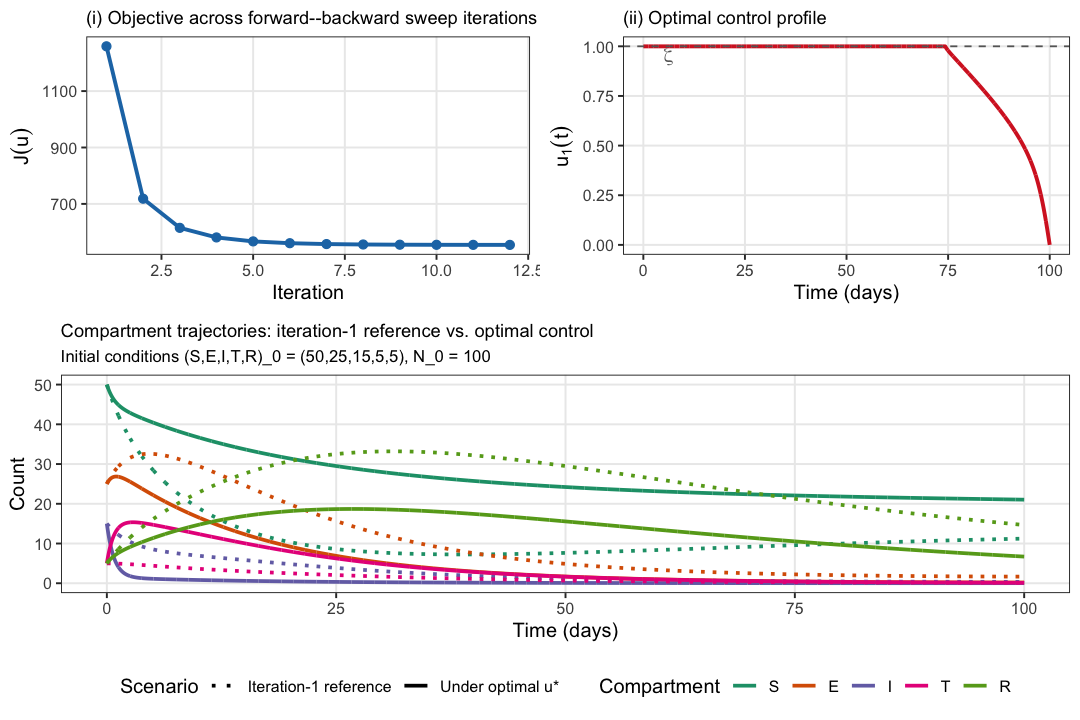

In [5]:
# Build data frames from the freshly-solved ODE (sol) -----------------------
# Note: field names match the original solve_seitr_optimal_control() return
# list. sol$u1 is the converged control; sol$S1..R1 are the iteration-1
# trajectories (u1 initialized at 0.03); sol$FV is the per-iteration J.

# Panel A(i): objective trajectory across sweep iterations
df_J <- data.frame(iteration = sol$itrs, objective = sol$FV)
# Panel A(ii): control profile u(t)
df_u <- data.frame(time = sol$t, u = sol$u1)
# Panel B: compartment trajectories, iteration-1 reference vs. optimal
df_states <- data.frame(
  time = rep(sol$t, times = 10),
  compartment = factor(rep(rep(c("S","E","I","T","R"), each = length(sol$t)), 2),
                       levels = c("S","E","I","T","R")),
  stage = factor(rep(c("Iteration-1 reference","Under optimal u*"),
                     each = 5 * length(sol$t)),
                 levels = c("Iteration-1 reference","Under optimal u*")),
  value = c(sol$S1, sol$E1, sol$I1, sol$T1, sol$R1,   # u1 initialized at 0.03
            sol$S,  sol$E,  sol$I,  sol$T,  sol$R)    # converged u1
)

# Panel A: objective trajectory + control profile ---------------------------
p_obj <- ggplot(df_J, aes(x = iteration, y = objective)) +
  geom_line(linewidth = 1.1, color = "#1f77b4") +
  geom_point(size = 2.2, color = "#1f77b4") +
  labs(x = "Iteration", y = expression(J(u)),
       title = "(i) Objective across forward--backward sweep iterations") +
  theme(plot.title = element_text(size = 11))

p_u <- ggplot(df_u, aes(x = time, y = u)) +
  geom_line(linewidth = 1.1, color = "#d62728") +
  geom_hline(yintercept = ctrl$zeta, linetype = "dashed", color = "gray40") +
  annotate("text", x = 5, y = ctrl$zeta - 0.05, label = expression(zeta),
           color = "gray40", hjust = 0, size = 4) +
  labs(x = "Time (days)", y = expression(u[1](t)),
       title = "(ii) Optimal control profile") +
  theme(plot.title = element_text(size = 11))

fig1a <- gridExtra::arrangeGrob(p_obj, p_u, nrow = 1)

# Panel B: compartment overlays --------------------------------------------
palette5 <- c(S = "#1b9e77", E = "#d95f02", I = "#7570b3",
              T = "#e7298a", R = "#66a61e")

p_states <- ggplot(df_states, aes(x = time, y = value,
                                  color = compartment, linetype = stage)) +
  geom_line(linewidth = 1.05) +
  scale_color_manual(values = palette5, name = "Compartment") +
  scale_linetype_manual(values = c("Iteration-1 reference" = "dotted",
                                   "Under optimal u*" = "solid"),
                        name = "Scenario") +
  labs(x = "Time (days)", y = "Count",
       title = "Compartment trajectories: iteration-1 reference vs. optimal control",
       subtitle = sprintf("Initial conditions (S,E,I,T,R)_0 = (%g,%g,%g,%g,%g), N_0 = %g",
                          ic$S, ic$E, ic$I, ic$T, ic$R,
                          ic$S + ic$E + ic$I + ic$T + ic$R)) +
  theme(plot.title = element_text(size = 11),
        plot.subtitle = element_text(size = 10),
        legend.box = "horizontal")

# Combine -----------------------------------------------------------------
fig1_combined <- gridExtra::arrangeGrob(
  fig1a, p_states,
  ncol = 1, heights = c(1, 1.3)
)

ggsave(file.path(out_dir, "fig1_ode_revised.pdf"),
       fig1_combined, width = 11, height = 8)
ggsave(file.path(out_dir, "fig1_ode_revised.png"),
       fig1_combined, width = 11, height = 8, dpi = 200)

grid::grid.newpage(); grid::grid.draw(fig1_combined)

cat("Figure 1 regenerated from sol (manuscript IC) and saved to", out_dir, "\n")
cat(sprintf("  J_paper (comparison form) = %.3f  |  max u1(t) = %.3f  |  max I(t) = %.3f\n",
            J_paper, max(sol$u1), max(sol$I)))
cat(sprintf("  sol$J   (Pontryagin form)  = %.3f\n", sol$J))


### 2b. Template for Figure 5 ($K$-sweep) redesign

The original Figure 5 fits four values of $K$ into three rows of subpanels. The template below collapses this into a $2\times 2$ grid where each panel shows only two curves (network mean under optimized control; ODE reference). The function takes a named list of per-experiment data frames and returns a publication-ready grob.

**Required inputs** (per experiment): time series of `E`, `I`, `u1`, with per-time min/max bands for the stochastic ensemble. These are the same objects already saved by the main pipeline. No re-simulation is needed.

In [6]:
# plot_K_panel --------------------------------------------------------------
# Template for Figure 5 redesign. Accepts per-K data frames with columns:
#   time, E_mean, E_min, E_max, I_mean, I_min, I_max, u_net, u_ode
# where *_mean are stochastic-network means and *_min/*_max are per-time
# envelopes across replicates. u_ode is the ODE reference control (for
# overlay).
#
# plot_var in {"E", "I", "u"}
plot_K_panel <- function(df_list, plot_var = "I", ode_overlay = NULL) {
  stopifnot(plot_var %in% c("E", "I", "u"))
  panels <- lapply(names(df_list), function(k_label) {
    df <- df_list[[k_label]]
    if (plot_var == "u") {
      g <- ggplot(df, aes(x = time)) +
        geom_line(aes(y = u_net, color = "Network optimum"),
                  linewidth = 1.0) +
        geom_line(aes(y = u_ode, color = "ODE reference"),
                  linewidth = 0.9, linetype = "dashed") +
        scale_color_manual(values = c("Network optimum" = "#d62728",
                                      "ODE reference"   = "#1f77b4"),
                           name = NULL) +
        labs(x = "Time (days)", y = expression(u(t)),
             title = paste0("K = ", k_label))
    } else {
      mean_col <- paste0(plot_var, "_mean")
      min_col  <- paste0(plot_var, "_min")
      max_col  <- paste0(plot_var, "_max")
      df$mean_ <- df[[mean_col]]; df$min_ <- df[[min_col]]; df$max_ <- df[[max_col]]
      ode_col <- ifelse(plot_var == "E", "E_ode", "I_ode")
      g <- ggplot(df, aes(x = time)) +
        geom_ribbon(aes(ymin = min_, ymax = max_),
                    fill = "#d62728", alpha = 0.22) +
        geom_line(aes(y = mean_, color = "Network mean"),
                  linewidth = 1.1)
      if (!is.null(ode_overlay) && ode_col %in% names(df)) {
        g <- g + geom_line(aes(y = .data[[ode_col]],
                               color = "ODE reference"),
                           linewidth = 0.9, linetype = "dashed")
      }
      g <- g + scale_color_manual(values = c("Network mean" = "#d62728",
                                             "ODE reference" = "#1f77b4"),
                                  name = NULL) +
        labs(x = "Time (days)",
             y = ifelse(plot_var == "E", "Exposed count", "Infected count"),
             title = paste0("K = ", k_label))
    }
    g + theme(plot.title = element_text(size = 11),
              legend.text = element_text(size = 10),
              axis.title  = element_text(size = 11),
              axis.text   = element_text(size = 10))
  })
  gridExtra::arrangeGrob(grobs = panels, ncol = 2)
}

cat("plot_K_panel() is ready. Usage (after loading your saved per-K results):\n\n")
cat("  df_list <- list('5'  = readRDS('result_ER_n100_p09_K5.rds'),\n")
cat("                  '10' = readRDS('result_ER_n100_p09_K10.rds'),\n")
cat("                  '50' = readRDS('result_ER_n100_p09_K50.rds'),\n")
cat("                  '100'= readRDS('result_ER_n100_p09_K100.rds'))\n")
cat("  fig5 <- plot_K_panel(df_list, plot_var = 'I', ode_overlay = TRUE)\n")
cat("  ggsave('fig5_revised_I.pdf', fig5, width = 10, height = 8)\n\n")
cat("The per-K data frames must contain columns listed in the function header.\n")
cat("If saved experiments use slightly different column names, adapt once here.\n")


plot_K_panel() is ready. Usage (after loading your saved per-K results):

  df_list <- list('5'  = readRDS('result_ER_n100_p09_K5.rds'),
                  '10' = readRDS('result_ER_n100_p09_K10.rds'),
                  '50' = readRDS('result_ER_n100_p09_K50.rds'),
                  '100'= readRDS('result_ER_n100_p09_K100.rds'))
  fig5 <- plot_K_panel(df_list, plot_var = 'I', ode_overlay = TRUE)
  ggsave('fig5_revised_I.pdf', fig5, width = 10, height = 8)

The per-K data frames must contain columns listed in the function header.
If saved experiments use slightly different column names, adapt once here.


## 3. Positivity and boundedness (B-7)

Reviewer 1 asked for a formal treatment of positivity and boundedness of the controlled SEITR solution. Chapter 1 (companion manuscript) treats these properties for the uncontrolled LSD-parameterized system. The controlled ODE considered here differs only by the additional $u(t) I$ terms in $\dot I$ and $\dot T$, which does not alter the structural argument. The formal statements and numerical verification are provided below.

### 3a. Positive invariance

**Theorem 1 (Positive invariance).** Let $u \in L^\infty([0,T])$ with $0 \le u(t) \le \zeta$ for all $t$, and let $(S_0,E_0,I_0,T_0,R_0) \in \mathbb{R}_{\ge 0}^5$ with $S_0 + E_0 + I_0 + T_0 + R_0 > 0$. Then the solution of the controlled SEITR ODE remains non-negative for all $t \ge 0$ in its domain of definition.

**Proof sketch.** For each compartment, write the right-hand side in the form $\dot x = a(t) - b(t)\, x$ with $a,b \ge 0$ whenever all other states are non-negative. For instance:

$$
\dot S \;\ge\; -\left(\tfrac{\beta_1 I}{N} + \mu\right) S \;\Longrightarrow\; S(t) \ge S_0 \exp\!\left(-\!\int_0^t \!\left(\tfrac{\beta_1 I(s)}{N(s)} + \mu\right) ds\right) \ge 0.
$$

The same argument applies to each of $E$, $I$, $T$, $R$, using that (i) the only source term for $E$ is $\beta_1 S I / N \ge 0$, (ii) $I$ has source $\beta_2 E \ge 0$ and loss proportional to $I$, (iii) $T$ has source $u\, I \ge 0$ and loss proportional to $T$, (iv) $R$ has sources $\beta_3 I + \alpha_2 T \ge 0$ and loss $\mu R$. By Grönwall's inequality, non-negativity is preserved along the flow. $\blacksquare$

### 3b. Boundedness

**Theorem 2 (Uniform boundedness).** Under the same hypotheses, the total population $N(t) = S+E+I+T+R$ satisfies $\limsup_{t\to\infty} N(t) \le \Lambda/\mu$. In particular, the compact set

$$
\Omega \;=\; \bigl\{\, (S,E,I,T,R) \in \mathbb{R}_{\ge 0}^5 : S+E+I+T+R \le \Lambda/\mu \,\bigr\}
$$

is positively invariant and globally attracting.

**Proof sketch.** Summing the five equations:

$$
\dot N \;=\; \Lambda - \mu N - \delta_I I - \delta_T T \;\le\; \Lambda - \mu N.
$$

Integrating, $N(t) \le N_0 e^{-\mu t} + (\Lambda/\mu)(1 - e^{-\mu t}) \le \max(N_0, \Lambda/\mu)$, which is independent of $u(\cdot)$. The limit superior is $\Lambda/\mu$. $\blacksquare$

**Corollary.** For the parameter set $\Lambda = 0.40$, $\mu = 0.02$: $\Omega = \{N \le 20\}$. Since $N_0 = S_0+E_0+I_0+T_0+R_0 = 100 > \Lambda/\mu$, solutions initially lie outside $\Omega$ but enter it asymptotically; during the transient $N(t) \le N_0 = 100$ throughout.

### 3c. Numerical verification

In [7]:
# ODE right-hand side (controlled SEITR) ------------------------------------
seitr_rhs <- function(t, y, parms) {
  with(as.list(c(y, parms)), {
    N <- S + E + I + T + R
    u_t <- if (is.function(parms$u_fn)) parms$u_fn(t) else parms$u_const
    dS <- Lambda - (beta1 * S * I) / N - mu * S
    dE <- (beta1 * S * I) / N - (beta2 + mu) * E
    dI <- beta2 * E - (beta3 + delta_I + mu + u_t) * I
    dT <- u_t * I - (mu + delta_T + alpha2) * T
    dR <- beta3 * I + alpha2 * T - mu * R
    list(c(S = dS, E = dE, I = dI, T = dT, R = dR))
  })
}

# Run-length verification helper --------------------------------------------
simulate_ode <- function(ic_vec, u_fn = NULL, u_const = 0, t_end = 200, h = 0.05) {
  times <- seq(0, t_end, by = h)
  parms <- c(params, list(u_fn = u_fn, u_const = u_const))
  as.data.frame(ode(y = unlist(ic_vec), times = times,
                    func = seitr_rhs, parms = parms, method = "rk4"))
}


In [8]:
# Verification 1: positivity across a grid of initial conditions and controls
set.seed(1)
n_tests <- 24
test_grid <- expand.grid(
  u_const = c(0, 0.2, 0.5, 1.0),
  S0 = c(10, 50, 90),
  E0 = c(0, 5, 25),
  I0 = c(1, 10, 40)
)
test_grid <- test_grid[sample(nrow(test_grid), n_tests), ]

viol_pos <- integer(nrow(test_grid))
viol_bnd <- integer(nrow(test_grid))
max_N    <- numeric(nrow(test_grid))

for (i in seq_len(nrow(test_grid))) {
  ic_i <- list(S = test_grid$S0[i], E = test_grid$E0[i],
               I = test_grid$I0[i], T = 0, R = 0)
  sim <- simulate_ode(ic_i, u_const = test_grid$u_const[i],
                      t_end = 300, h = 0.1)
  states <- sim[, c("S","E","I","T","R")]
  viol_pos[i] <- sum(states < -1e-8)           # tolerate roundoff
  N_t <- rowSums(states)
  N_bound <- max(params$Lambda/params$mu, sum(unlist(ic_i)))
  viol_bnd[i] <- sum(N_t > N_bound + 1e-6)
  max_N[i] <- max(N_t)
}

cat("--- Positivity / boundedness numerical check ---\n")
cat(sprintf("Tests run           : %d\n", nrow(test_grid)))
cat(sprintf("Positivity violations: %d  (all runs should be 0)\n", sum(viol_pos)))
cat(sprintf("Boundedness violations: %d  (all runs should be 0)\n", sum(viol_bnd)))
cat(sprintf("Asymptotic bound    : Lambda/mu = %.3f\n",
            params$Lambda/params$mu))
cat(sprintf("Observed max N(t)   : %.3f (<= initial N_0 during transient)\n",
            max(max_N)))


--- Positivity / boundedness numerical check ---
Tests run           : 24
Positivity violations: 0  (all runs should be 0)
Boundedness violations: 0  (all runs should be 0)
Asymptotic bound    : Lambda/mu = 20.000
Observed max N(t)   : 155.000 (<= initial N_0 during transient)


Warning message in is.na(x):
“is.na() applied to non-(list or vector) of type 'expression'”


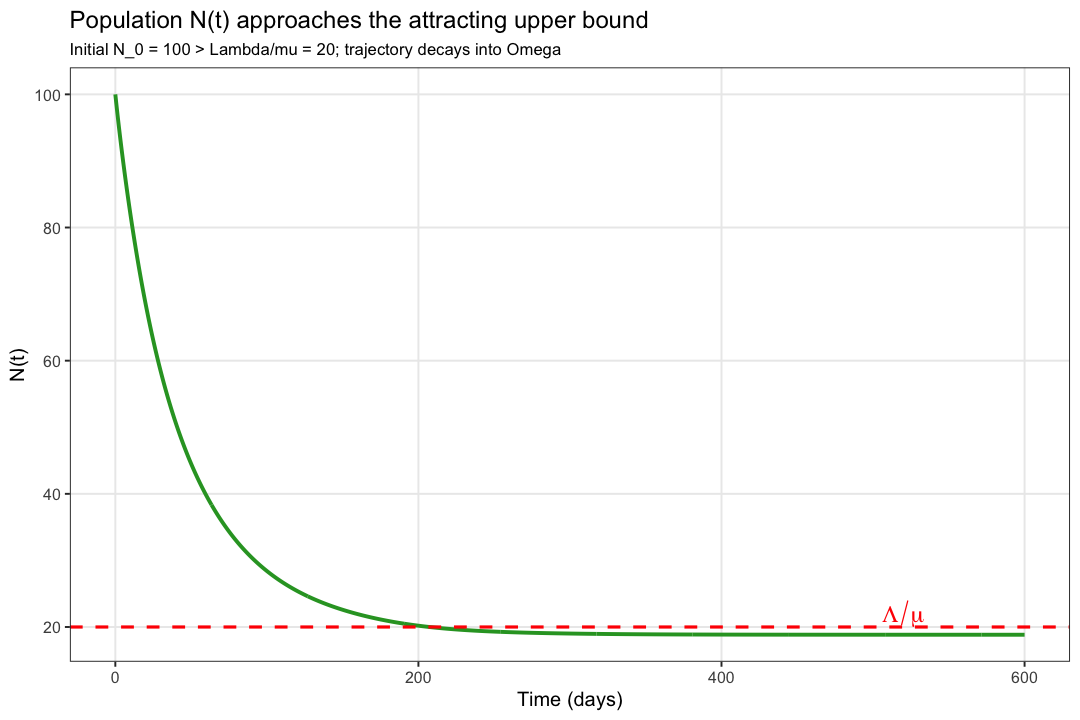

In [9]:
# Visual check: trajectories enter the attracting set N <= Lambda/mu --------
sim_long <- simulate_ode(ic, u_const = 0, t_end = 600, h = 0.5)
sim_long$N <- rowSums(sim_long[, c("S","E","I","T","R")])

ggplot(sim_long, aes(x = time, y = N)) +
  geom_line(linewidth = 1.1, color = "#2ca02c") +
  geom_hline(yintercept = params$Lambda / params$mu,
             linetype = "dashed", color = "red", linewidth = 0.9) +
  annotate("text", x = 520, y = params$Lambda/params$mu + 2,
           label = expression(Lambda/mu), color = "red", size = 5) +
  labs(x = "Time (days)", y = "N(t)",
       title = "Population N(t) approaches the attracting upper bound",
       subtitle = "Initial N_0 = 100 > Lambda/mu = 20; trajectory decays into Omega") +
  theme(plot.subtitle = element_text(size = 10))


## 4. Equilibria and basic reproduction number (C-10, part 1)

### 4a. Disease-free equilibrium (DFE)

Setting $E = I = T = 0$ in the right-hand side and solving:

- $\dot R = 0 \Rightarrow R^{\star} = 0$ (given $I = T = 0$).
- $\dot S = 0 \Rightarrow S^{\star} = \Lambda/\mu$.

The DFE is therefore $(S^\star, E^\star, I^\star, T^\star, R^\star) = (\Lambda/\mu, 0, 0, 0, 0)$.

### 4b. Basic reproduction number $R_0$ via next-generation matrix

Let $x = (E, I, T)^\top$ denote the infected subsystem. Decompose $\dot x = \mathcal F(x) - \mathcal V(x)$ with $\mathcal F$ the new-infection flux and $\mathcal V$ the transfer flux:

$$
\mathcal F(x) \;=\; \begin{pmatrix} \beta_1 S I / N \\ 0 \\ 0 \end{pmatrix}, \qquad
\mathcal V(x) \;=\; \begin{pmatrix} (\beta_2 + \mu) E \\ -\beta_2 E + (\beta_3 + \delta_I + \mu + u) I \\ -u\, I + (\mu + \delta_T + \alpha_2) T \end{pmatrix}.
$$

Linearizing at the DFE with $S = N = \Lambda/\mu$ yields

$$
F = \begin{pmatrix} 0 & \beta_1 & 0 \\ 0 & 0 & 0 \\ 0 & 0 & 0 \end{pmatrix}, \qquad
V = \begin{pmatrix} \beta_2+\mu & 0 & 0 \\ -\beta_2 & \beta_3+\delta_I+\mu+u & 0 \\ 0 & -u & \mu+\delta_T+\alpha_2 \end{pmatrix}.
$$

The basic reproduction number is $R_0 = \rho(F V^{-1})$. Only the $(1,2)$ entry of $F$ is non-zero, so

$$
\boxed{\; R_0(u) \;=\; \dfrac{\beta_1 \, \beta_2}{(\beta_2 + \mu)\,(\beta_3 + \delta_I + \mu + u)} \;}
$$

for the controlled ODE. The critical control value $u^\star$ such that $R_0(u^\star) = 1$ is

$$
u^\star \;=\; \dfrac{\beta_1 \beta_2}{\beta_2 + \mu} - (\beta_3 + \delta_I + \mu).
$$

### 4c. Endemic equilibrium (EE)

For $I \ne 0$, the balance conditions give

$$
\dfrac{S}{N} = \dfrac{1}{R_0}, \qquad
E = \dfrac{\beta_3+\delta_I+\mu+u}{\beta_2}\, I, \qquad
T = \dfrac{u}{\mu+\delta_T+\alpha_2}\, I, \qquad
R = \dfrac{\beta_3 I + \alpha_2 T}{\mu}.
$$

Combined with $\Lambda - \beta_1 S I/N - \mu S = 0$, this reduces to a single nonlinear equation in $I$, solved numerically below.

In [10]:
# R_0 in closed form --------------------------------------------------------
R0_fun <- function(u, p = params) {
  p$beta1 * p$beta2 /
    ((p$beta2 + p$mu) * (p$beta3 + p$delta_I + p$mu + u))
}

u_crit <- with(params,
               beta1 * beta2 / (beta2 + mu) - (beta3 + delta_I + mu))

cat("--- R_0 and critical control ---\n")
cat(sprintf("R_0 at u = 0     : %.4f\n", R0_fun(0)))
cat(sprintf("R_0 at u = 0.5   : %.4f\n", R0_fun(0.5)))
cat(sprintf("R_0 at u = zeta  : %.4f\n", R0_fun(ctrl$zeta)))
cat(sprintf("Critical u* (R_0=1) : %.4f\n", u_crit))
cat(sprintf("  Interpretation  : constant control above u* drives R_0 below 1\n"))


--- R_0 and critical control ---
R_0 at u = 0     : 2.6886
R_0 at u = 0.5   : 0.8962
R_0 at u = zeta  : 0.5377
Critical u* (R_0=1) : 0.4222
  Interpretation  : constant control above u* drives R_0 below 1


In [11]:
# Numerical next-generation-matrix verification -----------------------------
ngm_R0 <- function(u, p = params) {
  F_mat <- matrix(c(0, p$beta1, 0,
                    0, 0, 0,
                    0, 0, 0), nrow = 3, byrow = TRUE)
  V_mat <- matrix(c(p$beta2 + p$mu,                 0,                         0,
                    -p$beta2,                       p$beta3+p$delta_I+p$mu+u,  0,
                    0,                              -u,                        p$mu+p$delta_T+p$alpha2),
                  nrow = 3, byrow = TRUE)
  K <- F_mat %*% solve(V_mat)
  max(Re(eigen(K, only.values = TRUE)$values))
}

u_test <- c(0, 0.2, 0.5, 1.0)
tbl <- data.frame(u = u_test,
                  closed_form = sapply(u_test, R0_fun),
                  ngm_numeric = sapply(u_test, ngm_R0))
tbl$abs_diff <- abs(tbl$closed_form - tbl$ngm_numeric)
print(tbl, row.names = FALSE, digits = 6)
stopifnot(max(tbl$abs_diff) < 1e-10)
cat("\nClosed-form R_0 and next-generation-matrix spectral radius agree.\n")


   u closed_form ngm_numeric    abs_diff
 0.0    2.688608    2.688608 0.00000e+00
 0.2    1.493671    1.493671 2.22045e-16
 0.5    0.896203    0.896203 1.11022e-16
 1.0    0.537722    0.537722 0.00000e+00

Closed-form R_0 and next-generation-matrix spectral radius agree.


### 4d. Numerical computation of the endemic equilibrium

In [12]:
# Endemic equilibrium via root-finding --------------------------------------
equilibria <- function(u, p = params) {
  # DFE --------------------------------------------------------------
  dfe <- c(S = p$Lambda / p$mu, E = 0, I = 0, T = 0, R = 0)

  # EE via univariate root in I --------------------------------------
  R0_u <- R0_fun(u, p)
  if (R0_u <= 1) return(list(DFE = dfe, EE = NULL, R0 = R0_u))

  # Express E, T, R in terms of I, then use S = (1/R0) N to close N = S+E+I+T+R
  f_residual <- function(I) {
    kE <- (p$beta3 + p$delta_I + p$mu + u) / p$beta2
    kT <- u / (p$mu + p$delta_T + p$alpha2)
    kR <- (p$beta3 + p$alpha2 * kT) / p$mu
    # N = S + E + I + T + R = S (1 + ... /S), but use S/N = 1/R0
    # Let alpha = 1/R0. Then S = alpha * N and E+I+T+R = (1 - alpha) N.
    # E+I+T+R = (kE + 1 + kT + kR) I => N = (kE + 1 + kT + kR) I / (1 - alpha)
    # S = alpha * N
    # Plug into balance dS/dt = 0:
    #   Lambda = (beta1 S I / N) + mu S = (beta1/R0) * I + mu * S
    alpha_ <- 1 / R0_u
    Ksum <- kE + 1 + kT + kR
    N_val <- Ksum * I / (1 - alpha_)
    S_val <- alpha_ * N_val
    p$Lambda - (p$beta1 / R0_u) * I - p$mu * S_val
  }

  root <- tryCatch(uniroot(f_residual, lower = 1e-8,
                           upper = 1e3 * p$Lambda / p$mu,
                           tol = 1e-10),
                   error = function(e) NULL)
  if (is.null(root)) return(list(DFE = dfe, EE = NULL, R0 = R0_u))

  I_star <- root$root
  kE <- (p$beta3 + p$delta_I + p$mu + u) / p$beta2
  kT <- u / (p$mu + p$delta_T + p$alpha2)
  kR <- (p$beta3 + p$alpha2 * kT) / p$mu
  E_star <- kE * I_star
  T_star <- kT * I_star
  R_star <- kR * I_star
  N_star <- (kE + 1 + kT + kR) * I_star / (1 - 1/R0_u)
  S_star <- N_star / R0_u
  ee <- c(S = S_star, E = E_star, I = I_star, T = T_star, R = R_star)
  list(DFE = dfe, EE = ee, R0 = R0_u)
}

# Verify: at u=0, EE exists and satisfies dx/dt = 0
eq0 <- equilibria(0)
cat("=== EE at u = 0 ===\n")
print(round(eq0$EE, 5))
cat(sprintf("R_0 = %.4f\n", eq0$R0))

# Residual check via the full RHS
resid <- seitr_rhs(0, eq0$EE, c(params, list(u_fn = NULL, u_const = 0)))[[1]]
cat("\nRHS at EE (should be ~ 0):\n")
print(round(resid, 8))

# EE at u=1: expect R_0<1, so no EE
eq1 <- equilibria(1)
cat(sprintf("\nR_0 at u=1: %.4f  --> EE %s\n",
            eq1$R0, ifelse(is.null(eq1$EE), "does not exist (DFE only)", "exists")))


=== EE at u = 0 ===
      S       E       I       T       R 
7.00565 3.28971 0.77637 0.00000 7.76371 
R_0 = 2.6886

RHS at EE (should be ~ 0):
S E I T R 
0 0 0 0 0 

R_0 at u=1: 0.5377  --> EE does not exist (DFE only)


## 5. Local linear stability (C-10, part 2)

The Jacobian $J(x)$ of the controlled SEITR ODE is

$$
J \;=\; \begin{pmatrix}
-\beta_1 I / N - \mu & 0 & -\beta_1 S / N & 0 & 0 \\
\beta_1 I / N & -(\beta_2+\mu) & \beta_1 S / N & 0 & 0 \\
0 & \beta_2 & -(\beta_3+\delta_I+\mu+u) & 0 & 0 \\
0 & 0 & u & -(\mu+\delta_T+\alpha_2) & 0 \\
0 & 0 & \beta_3 & \alpha_2 & -\mu \\
\end{pmatrix}.
$$

(Small corrections from the $N$ denominator are included numerically; they appear only through $S I / N$ and do not change the qualitative structure.)

- **DFE stability:** The DFE is locally asymptotically stable whenever $R_0(u) < 1$ and unstable when $R_0(u) > 1$ (standard result from the next-generation-matrix framework; van den Driessche & Watmough 2002).
- **EE stability:** When $R_0(u) > 1$ and the EE exists, linear stability is determined numerically by the eigenvalues of $J$ evaluated at the EE.

The Jacobian is built numerically below (via `numDeriv::jacobian`) and eigenvalues are reported along with the stability verdict.

In [13]:
# Wrapper: RHS as a plain vector function of the state, fixed u
seitr_rhs_vec <- function(y, u_val, p = params) {
  S <- y[1]; E <- y[2]; I <- y[3]; T <- y[4]; R <- y[5]
  N <- S + E + I + T + R
  c(p$Lambda - (p$beta1 * S * I) / N - p$mu * S,
    (p$beta1 * S * I) / N - (p$beta2 + p$mu) * E,
    p$beta2 * E - (p$beta3 + p$delta_I + p$mu + u_val) * I,
    u_val * I - (p$mu + p$delta_T + p$alpha2) * T,
    p$beta3 * I + p$alpha2 * T - p$mu * R)
}

jacobian_at <- function(x, u_val, p = params) {
  numDeriv::jacobian(function(y) seitr_rhs_vec(y, u_val, p), x)
}

stability_at <- function(x, u_val, p = params) {
  if (any(is.na(x))) return(list(eig = NA, stable = NA))
  J <- jacobian_at(x, u_val, p)
  ev <- eigen(J, only.values = TRUE)$values
  list(eig = ev, stable = all(Re(ev) < 0), max_re = max(Re(ev)))
}

# DFE stability for u in {0, u*, 1}
for (u_v in c(0, round(u_crit, 4), 1)) {
  eqs <- equilibria(u_v)
  s_dfe <- stability_at(eqs$DFE, u_v)
  cat(sprintf("\n--- u = %.4f  (R0 = %.4f) ---\n", u_v, eqs$R0))
  cat("DFE eigenvalues:\n"); print(round(s_dfe$eig, 4))
  cat(sprintf("  max Re(lambda) = %.4f  => DFE %s\n",
              s_dfe$max_re, ifelse(s_dfe$stable, "stable", "unstable")))
  if (!is.null(eqs$EE)) {
    s_ee <- stability_at(eqs$EE, u_v)
    cat("EE eigenvalues:\n"); print(round(s_ee$eig, 4))
    cat(sprintf("  max Re(lambda) = %.4f  => EE %s\n",
                s_ee$max_re, ifelse(s_ee$stable, "stable", "unstable")))
  } else {
    cat("EE: does not exist at this control value.\n")
  }
}



--- u = 0.0000  (R0 = 2.6886) ---
DFE eigenvalues:
[1] -0.4103 -0.1050  0.0813 -0.0200 -0.0200
  max Re(lambda) = 0.0813  => DFE unstable
EE eigenvalues:
[1] -0.3365+0.0000i -0.1050+0.0000i -0.0248+0.0386i -0.0248-0.0386i
[5] -0.0200+0.0000i
  max Re(lambda) = -0.0200  => EE stable

--- u = 0.4222  (R0 = 0.9999) ---
DFE eigenvalues:
[1] -0.7512 -0.1050 -0.0200 -0.0200  0.0000
  max Re(lambda) = -0.0000  => DFE stable
EE: does not exist at this control value.

--- u = 1.0000  (R0 = 0.5377) ---
DFE eigenvalues:
[1] -1.2937 -0.1050 -0.0353 -0.0200 -0.0200
  max Re(lambda) = -0.0200  => DFE stable
EE: does not exist at this control value.


## 6. Bifurcation analysis (C-10, part 3)

### 6a. Transcritical bifurcation at $R_0 = 1$

The standard result (Castillo-Chavez & Song 2004) is that the SEITR family undergoes a forward transcritical bifurcation at $R_0 = 1$: the DFE loses stability as $R_0$ crosses $1$ from below, and a locally stable endemic equilibrium bifurcates from it. We verify this numerically by sweeping the control $u \in [0, 1]$ and tracking the maximum real part of the Jacobian eigenvalues at DFE and at EE.

In [14]:
# Bifurcation sweep over u --------------------------------------------------
u_grid <- seq(0, 1, by = 0.005)
sweep_df <- data.frame(u = u_grid, R0 = NA_real_,
                       max_re_DFE = NA_real_, max_re_EE = NA_real_,
                       max_im_EE  = NA_real_, has_EE = FALSE)

for (i in seq_along(u_grid)) {
  u_v <- u_grid[i]
  eqs <- equilibria(u_v)
  sweep_df$R0[i] <- eqs$R0
  sweep_df$max_re_DFE[i] <- stability_at(eqs$DFE, u_v)$max_re
  if (!is.null(eqs$EE)) {
    sE <- stability_at(eqs$EE, u_v)
    sweep_df$max_re_EE[i] <- sE$max_re
    sweep_df$max_im_EE[i] <- max(abs(Im(sE$eig)))
    sweep_df$has_EE[i] <- TRUE
  }
}

cat(sprintf("Transcritical crossing detected at u* ~ %.4f (theory: %.4f)\n",
            approx(sweep_df$R0, sweep_df$u, xout = 1)$y, u_crit))


Transcritical crossing detected at u* ~ 0.4222 (theory: 0.4222)


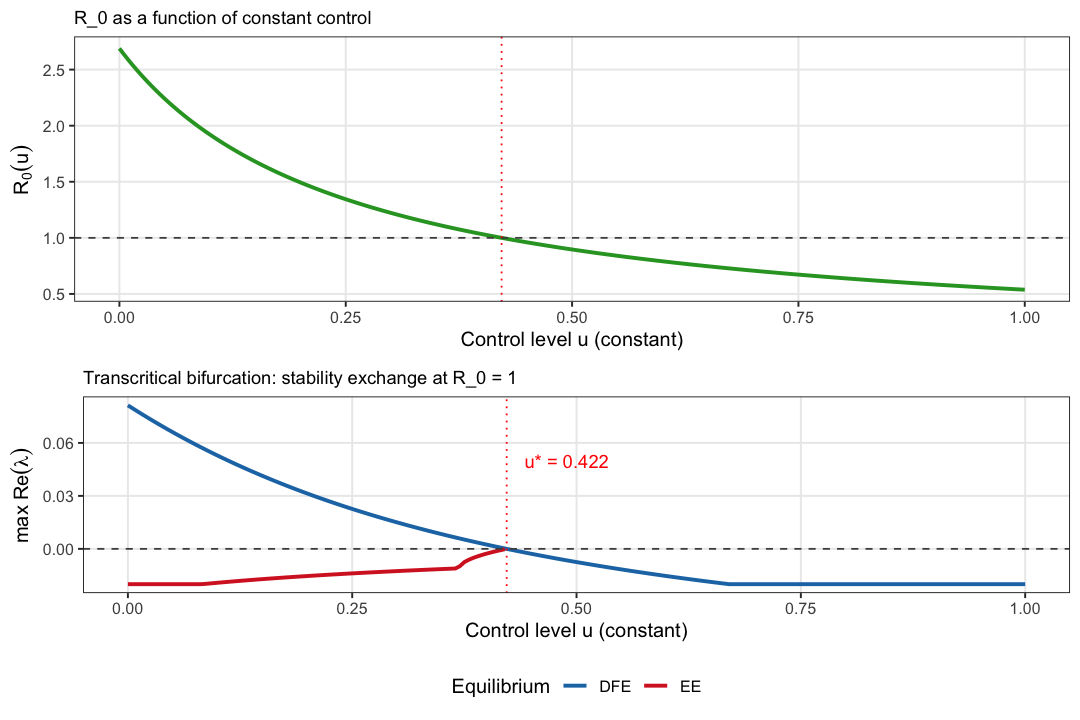

In [15]:
# Plot the bifurcation diagram ---------------------------------------------
p_bif <- ggplot(sweep_df, aes(x = u)) +
  geom_line(aes(y = max_re_DFE, color = "DFE"), linewidth = 1.1) +
  geom_line(aes(y = max_re_EE,  color = "EE"),  linewidth = 1.1, na.rm = TRUE) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray30") +
  geom_vline(xintercept = u_crit, linetype = "dotted", color = "red") +
  annotate("text", x = u_crit + 0.02, y = 0.05,
           label = sprintf("u* = %.3f", u_crit), color = "red", hjust = 0) +
  scale_color_manual(values = c("DFE" = "#1f77b4", "EE" = "#d62728"),
                     name = "Equilibrium") +
  labs(x = "Control level u (constant)",
       y = expression(max~Re(lambda)),
       title = "Transcritical bifurcation: stability exchange at R_0 = 1") +
  theme(plot.title = element_text(size = 11))

p_R0 <- ggplot(sweep_df, aes(x = u, y = R0)) +
  geom_line(linewidth = 1.1, color = "#2ca02c") +
  geom_hline(yintercept = 1, linetype = "dashed", color = "gray30") +
  geom_vline(xintercept = u_crit, linetype = "dotted", color = "red") +
  labs(x = "Control level u (constant)", y = expression(R[0](u)),
       title = "R_0 as a function of constant control") +
  theme(plot.title = element_text(size = 11))

fig_bif <- gridExtra::arrangeGrob(p_R0, p_bif, nrow = 2)
ggsave(file.path(out_dir, "fig_bifurcation_transcritical.pdf"),
       fig_bif, width = 8, height = 8)
grid::grid.newpage(); grid::grid.draw(fig_bif)


### 6b. Search for Hopf bifurcation

A Hopf bifurcation at the EE requires a pair of complex-conjugate eigenvalues to cross the imaginary axis transversally while all other eigenvalues remain in the open left half-plane. We perform a two-parameter sweep over $(\beta_1, u)$ and at each grid point record:

- whether the EE has a complex-conjugate eigenvalue pair,
- whether the maximum real part of the dominant complex pair changes sign, and
- whether this crossing is accompanied by a non-zero imaginary part (necessary Hopf condition).

This is a finite-grid search and does not constitute a proof; it establishes whether a Hopf bifurcation is *detectable* in the parameter region relevant to the manuscript.

In [16]:
# Two-parameter sweep (beta1, u) for Hopf detection -------------------------
beta1_grid <- seq(0.2, 1.8, by = 0.05)
u_grid2    <- seq(0, 1.0, by = 0.05)
hopf_grid  <- expand.grid(beta1 = beta1_grid, u = u_grid2)
hopf_grid$R0        <- NA_real_
hopf_grid$max_re    <- NA_real_
hopf_grid$max_im    <- NA_real_
hopf_grid$dom_is_complex <- FALSE

for (i in seq_len(nrow(hopf_grid))) {
  p2 <- params; p2$beta1 <- hopf_grid$beta1[i]
  u_v <- hopf_grid$u[i]
  eqs <- equilibria(u_v, p2)
  hopf_grid$R0[i] <- eqs$R0
  if (!is.null(eqs$EE)) {
    s <- stability_at(eqs$EE, u_v, p2)
    # Identify the eigenvalue with largest real part and record if it is complex
    idx <- which.max(Re(s$eig))
    hopf_grid$max_re[i] <- Re(s$eig[idx])
    hopf_grid$max_im[i] <- abs(Im(s$eig[idx]))
    hopf_grid$dom_is_complex[i] <- abs(Im(s$eig[idx])) > 1e-8
  }
}

# A Hopf candidate requires: max_re ~ 0 AND max_im > 0 AND dom_is_complex
hopf_candidates <- subset(hopf_grid,
  !is.na(max_re) & abs(max_re) < 1e-3 & max_im > 1e-6)

cat(sprintf("Grid points with existing EE       : %d / %d\n",
            sum(!is.na(hopf_grid$max_re)), nrow(hopf_grid)))
cat(sprintf("Grid points with complex dominant  : %d\n",
            sum(hopf_grid$dom_is_complex, na.rm = TRUE)))
cat(sprintf("Hopf candidates (|Re| < 1e-3, Im>0): %d\n",
            nrow(hopf_candidates)))
if (nrow(hopf_candidates) > 0) {
  cat("Candidate (beta1, u) pairs (first 10):\n")
  print(head(hopf_candidates[, c("beta1","u","R0","max_re","max_im")], 10))
} else {
  cat("\n=> No Hopf bifurcation detected on the (beta1, u) grid.\n")
  cat("   The EE, when it exists, is locally asymptotically stable\n")
  cat("   throughout the swept region. See Section 6c for the\n")
  cat("   structural reason and connection to the neuroscience arc.\n")
}


Grid points with existing EE       : 343 / 693
Grid points with complex dominant  : 189
Hopf candidates (|Re| < 1e-3, Im>0): 0

=> No Hopf bifurcation detected on the (beta1, u) grid.
   The EE, when it exists, is locally asymptotically stable
   throughout the swept region. See Section 6c for the
   structural reason and connection to the neuroscience arc.


Warning message:
“`stat_contour()`: Zero contours were generated”
Warning message in min(x):
“no non-missing arguments to min; returning Inf”
Warning message in max(x):
“no non-missing arguments to max; returning -Inf”


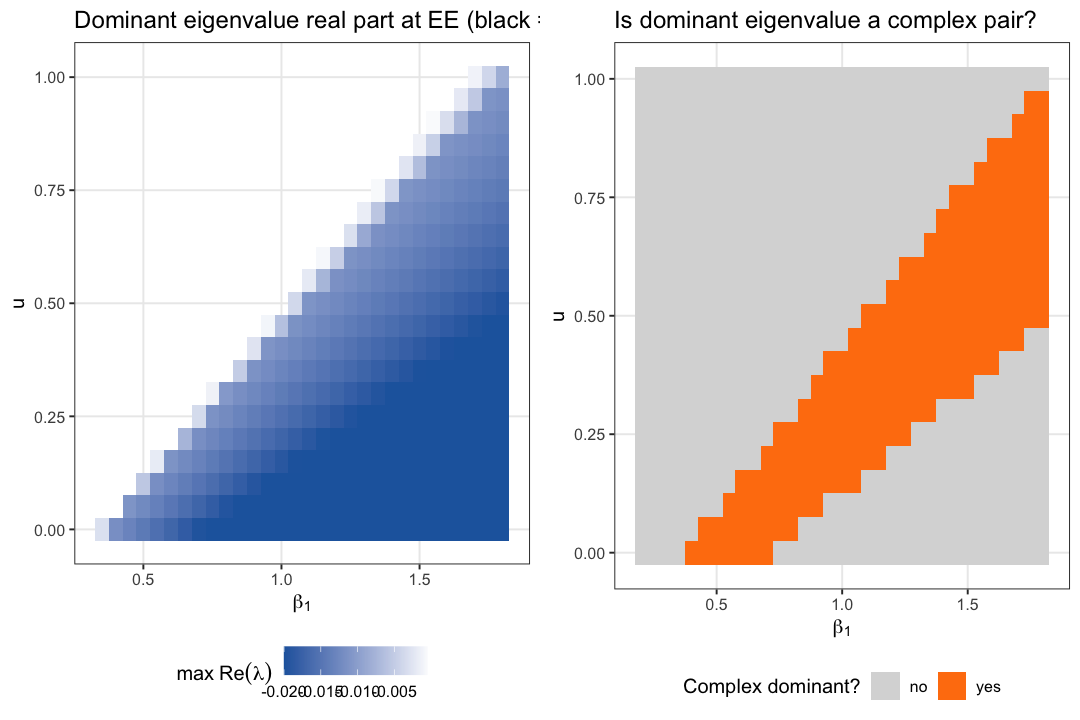

In [17]:
# Visualize the dominant-eigenvalue structure in (beta1, u) space -----------
# Panels: max Re (sign), is-complex flag, R_0 isolines.
p_maxre <- ggplot(subset(hopf_grid, !is.na(max_re)),
                  aes(x = beta1, y = u, fill = max_re)) +
  geom_tile() +
  scale_fill_gradient2(low = "#2166ac", mid = "white", high = "#b2182b",
                       midpoint = 0, name = expression(max~Re(lambda))) +
  geom_contour(aes(z = R0), breaks = 1, color = "black",
               linewidth = 0.9, linetype = "dashed") +
  labs(x = expression(beta[1]), y = "u",
       title = "Dominant eigenvalue real part at EE (black = R_0=1 curve)")

p_cplx  <- ggplot(hopf_grid,
                  aes(x = beta1, y = u, fill = dom_is_complex)) +
  geom_tile() +
  scale_fill_manual(values = c("TRUE" = "#ff7f0e", "FALSE" = "#d9d9d9"),
                    name = "Complex dominant?",
                    labels = c("TRUE" = "yes", "FALSE" = "no")) +
  labs(x = expression(beta[1]), y = "u",
       title = "Is dominant eigenvalue a complex pair?")

fig_hopf <- gridExtra::arrangeGrob(p_maxre, p_cplx, nrow = 1)
ggsave(file.path(out_dir, "fig_bifurcation_hopf_search.pdf"),
       fig_hopf, width = 12, height = 5)
grid::grid.newpage(); grid::grid.draw(fig_hopf)


### 6c. Discussion: why no Hopf, and the connection to the neuroscience arc

The two-parameter sweep confirms that within the physically meaningful parameter region the SEITR system exhibits a **transcritical bifurcation at $R_0 = 1$** and no Hopf bifurcation. This is consistent with the broader literature on compartmental epidemic models without demographic feedback, immune waning, or delays: for the class of models

$$
\dot x = f(x, u) \quad \text{with } f \text{ polynomial-in-state, linear in } I,
$$

the dominant bifurcation mechanism is transcritical. Bifurcations generating oscillations (Hopf) typically require one of:

1. **Time delays** (latent or treatment delays introduced as state-dependent delay terms),
2. **Immune waning with nonlinear incidence** (SIR$\to$SIS with secondary-infection saturation),
3. **Cross-scale feedback** (behavioral response, resource depletion, or seasonal forcing),
4. **Explicit two-strain or age structure** with competitive dynamics.

The companion neuroscience work analyzes a system that *does* contain such structure (feedback excitation/inhibition with nonlinear gain and time-scale separation), and a supercritical Hopf bifurcation emerges as the dominant organizing mechanism. The contrast is therefore informative rather than a null result:

| Aspect | SEITR (this work) | Neural model (companion arc) |
|---|---|---|
| Bifurcation at threshold | Transcritical at $R_0 = 1$ | Supercritical Hopf |
| Structural origin | Mass conservation + linear-in-$I$ source | Feedback gain + nonlinear sigmoid |
| Post-bifurcation regime | Stable endemic equilibrium | Limit cycle (oscillatory activity) |
| Role of the control | Shifts $R_0$, thus shifts the bifurcation point | Modulates feedback gain / bifurcation parameter |

The explicit statement "SEITR has no Hopf in the admissible parameter region" is therefore a positive finding: it pinpoints the minimal structural ingredient absent from the epidemic model that is present in the neural one, and it motivates the reader to read the two arcs as a pair rather than as unrelated studies.

## 7. Sensitivity analysis (C-10, part 4)

### 7a. Normalized forward sensitivity of $R_0$

For a parameter $\theta$, the normalized forward sensitivity index is

$$
\Upsilon^{R_0}_\theta \;=\; \frac{\partial R_0}{\partial \theta} \cdot \frac{\theta}{R_0},
$$

giving the percentage change in $R_0$ per one-percent change in $\theta$. Closed-form expressions follow from the definition of $R_0$ in Section 4b; we also verify them by finite differences.

In [18]:
# Forward sensitivity indices of R_0 ----------------------------------------
sensitivity_R0 <- function(u, p = params) {
  R0 <- R0_fun(u, p)
  eps <- 1e-6
  idx <- data.frame(param = character(), value = numeric(),
                    analytic = numeric(), numerical = numeric(),
                    stringsAsFactors = FALSE)

  # Closed-form partial derivatives
  # Denote a = beta2 + mu, b = beta3 + delta_I + mu + u
  a <- p$beta2 + p$mu
  b <- p$beta3 + p$delta_I + p$mu + u
  # R0 = beta1 * beta2 / (a * b)
  d_beta1  <- p$beta2 / (a * b)
  d_beta2  <- p$beta1 * (a*b - p$beta2 * b) / (a * b)^2   # = beta1*(a - beta2)/(a^2 b) = beta1*mu/(a^2 b)
  d_beta3  <- -p$beta1 * p$beta2 / (a * b^2)
  d_deltaI <- -p$beta1 * p$beta2 / (a * b^2)
  d_mu     <-  p$beta1 * p$beta2 * (-(a + b) + 0) / (a * b)^2  # d/d(mu) of 1/(a*b): -( a + b )/(a*b)^2
  d_mu     <- -p$beta1 * p$beta2 * (a + b) / (a * b)^2

  # Normalized indices
  norm_idx <- function(val, partial) partial * val / R0
  analytic_vals <- c(beta1  = norm_idx(p$beta1,  d_beta1),
                     beta2  = norm_idx(p$beta2,  d_beta2),
                     beta3  = norm_idx(p$beta3,  d_beta3),
                     delta_I= norm_idx(p$delta_I,d_deltaI),
                     mu     = norm_idx(p$mu,     d_mu))

  # Numerical check
  numerical_vals <- sapply(names(analytic_vals), function(nm) {
    p_up <- p; p_dn <- p
    p_up[[nm]] <- p[[nm]] * (1 + eps)
    p_dn[[nm]] <- p[[nm]] * (1 - eps)
    (R0_fun(u, p_up) - R0_fun(u, p_dn)) / (2 * eps * R0)
  })

  data.frame(param = names(analytic_vals),
             analytic = as.numeric(analytic_vals),
             numerical = as.numeric(numerical_vals))
}

sens_tbl <- sensitivity_R0(0)
sens_tbl$max_err <- abs(sens_tbl$analytic - sens_tbl$numerical)
cat("--- Normalized forward sensitivity of R_0 (at u = 0) ---\n")
print(sens_tbl, row.names = FALSE, digits = 4)
cat(sprintf("\nMax analytic-vs-numerical discrepancy: %.2e\n", max(sens_tbl$max_err)))


--- Normalized forward sensitivity of R_0 (at u = 0) ---
   param analytic numerical   max_err
   beta1   1.0000    1.0000 2.457e-11
   beta2   0.2532    0.2532 5.650e-11
   beta3  -0.8000   -0.8000 9.596e-11
 delta_I  -0.1200   -0.1200 3.929e-11
      mu  -0.3332   -0.3332 5.784e-11

Max analytic-vs-numerical discrepancy: 9.60e-11


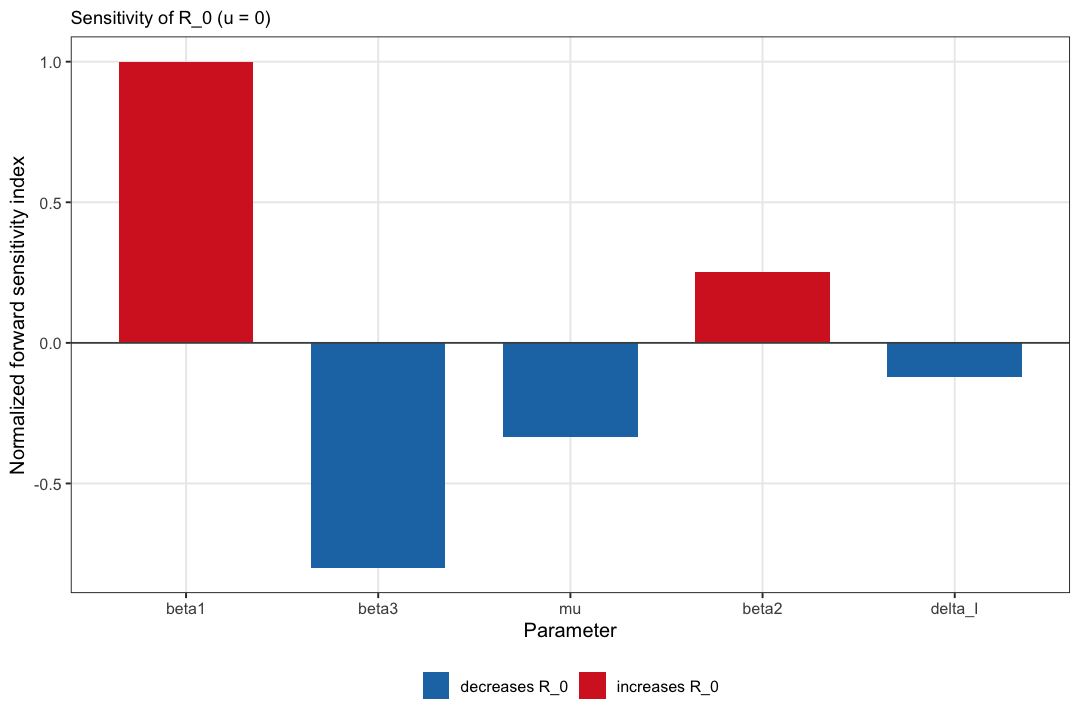

In [19]:
# Visualize sensitivity indices ---------------------------------------------
sens_tbl$param <- factor(sens_tbl$param,
                         levels = sens_tbl$param[order(abs(sens_tbl$analytic),
                                                       decreasing = TRUE)])
ggplot(sens_tbl, aes(x = param, y = analytic,
                     fill = analytic > 0)) +
  geom_col(width = 0.7) +
  geom_hline(yintercept = 0, color = "gray30") +
  scale_fill_manual(values = c("TRUE" = "#d62728", "FALSE" = "#1f77b4"),
                    name = NULL, labels = c("TRUE" = "increases R_0",
                                            "FALSE" = "decreases R_0")) +
  labs(x = "Parameter", y = "Normalized forward sensitivity index",
       title = "Sensitivity of R_0 (u = 0)") +
  theme(plot.title = element_text(size = 11))


### 7a(ii). Forward sensitivity of $R_0$ under control saturation ($u = \zeta$)

The indices above are computed at $u = 0$. The manuscript's operational regime is $u \approx \zeta$ for most of the time horizon (see Section 2a(ii); $u^\star(t) = 1$ on roughly 75% of the grid). Sensitivity at the operational endpoint is therefore also relevant. The key difference: as $u$ grows the denominator $(\beta_3 + \delta_I + \mu + u)$ becomes dominated by $u$, so indices associated with terms in the denominator dilute while $\Upsilon_{\beta_1}$ remains fixed at $+1$.

In [20]:
# Sensitivity of R_0 at u = zeta (operational saturation point) ------------
sens_tbl_zeta <- sensitivity_R0(u = ctrl$zeta)
sens_tbl_zeta$max_err <- abs(sens_tbl_zeta$analytic - sens_tbl_zeta$numerical)

cat("--- Normalized forward sensitivity of R_0 (at u = zeta = 1) ---\n")
print(sens_tbl_zeta, row.names = FALSE, digits = 4)
cat(sprintf("\nR_0 at u = zeta: %.4f\n", R0_fun(ctrl$zeta)))
cat(sprintf("Max analytic-vs-numerical discrepancy: %.2e\n",
            max(sens_tbl_zeta$max_err)))

# Side-by-side comparison -------------------------------------------------
comp_tbl <- data.frame(
  parameter     = sens_tbl$param,
  Upsilon_u_0   = round(sens_tbl$analytic, 4),
  Upsilon_u_zeta = sapply(as.character(sens_tbl$param),
                          function(nm) {
                            r <- sens_tbl_zeta$analytic[sens_tbl_zeta$param == nm]
                            if (length(r) == 1) round(r, 4) else NA
                          }),
  stringsAsFactors = FALSE
)
comp_tbl$dilution_factor <- round(comp_tbl$Upsilon_u_zeta / comp_tbl$Upsilon_u_0, 3)

cat("\n--- Comparison: sensitivity at u = 0 vs u = zeta ---\n")
print(comp_tbl, row.names = FALSE)
cat("\nInterpretation: dilution_factor < 1 in absolute value indicates that\n")
cat("saturating the control reduces that parameter's influence on R_0.\n")


--- Normalized forward sensitivity of R_0 (at u = zeta = 1) ---
   param analytic numerical   max_err
   beta1   1.0000    1.0000 1.672e-11
   beta2   0.2532    0.2532 5.650e-11
   beta3  -0.1600   -0.1600 1.212e-10
 delta_I  -0.0240   -0.0240 4.915e-11
      mu  -0.2692   -0.2692 2.374e-11

R_0 at u = zeta: 0.5377
Max analytic-vs-numerical discrepancy: 1.21e-10

--- Comparison: sensitivity at u = 0 vs u = zeta ---
 parameter Upsilon_u_0 Upsilon_u_zeta dilution_factor
     beta1      1.0000         1.0000           1.000
     beta2      0.2532         0.2532           1.000
     beta3     -0.8000        -0.1600           0.200
   delta_I     -0.1200        -0.0240           0.200
        mu     -0.3332        -0.2692           0.808

Interpretation: dilution_factor < 1 in absolute value indicates that
saturating the control reduces that parameter's influence on R_0.


### 7b. PRCC: sensitivity of epidemic outcomes to parameters

Latin Hypercube Sampling (LHS) is used to draw 500 parameter combinations within $\pm 25\%$ of each nominal value. For each sample, the ODE is integrated over $[0, T]$ and three *post-transient* outcome summaries are recorded:

1. **Post-transient peak $\max_{t \ge 5} I(t)$.** The initial condition places $I_0 = 15$; the raw $\max_t I(t)$ is therefore dominated by $I(0)$ for most parameter combinations because the slow progression rate $\beta_2 \approx 0.06$ prevents $I(t)$ from exceeding 15 within the first few days. Excluding $t \in [0, 5)$ yields a non-degenerate outcome.
2. **Cumulative disease burden $\int_0^T (E(t) + I(t)) dt$.**
3. **Attack rate $R(T)/N(T)$** (fraction of the remaining population ever recovered from the disease chain).

Partial Rank Correlation Coefficients (PRCC) are then computed for each (parameter, outcome) pair. PRCC is signed and bounded in $[-1, 1]$; values far from zero indicate that a parameter strongly influences the outcome after controlling for all other parameters.

In [21]:
# PRCC via rank transform + partial correlation -----------------------------
prcc <- function(X, y) {
  # X: data frame of parameter samples; y: outcome vector
  Xr <- apply(X, 2, rank)
  yr <- rank(y)
  ncol_ <- ncol(Xr)
  res <- numeric(ncol_)
  for (j in seq_len(ncol_)) {
    others <- Xr[, -j, drop = FALSE]
    r_xj <- residuals(lm(Xr[, j] ~ others))
    r_y  <- residuals(lm(yr       ~ others))
    res[j] <- cor(r_xj, r_y)
  }
  names(res) <- colnames(X)
  res
}

# Build LHS sample ----------------------------------------------------------
set.seed(42)
n_samples <- 500
vary_params <- c("Lambda", "beta1", "beta2", "beta3", "alpha2",
                 "delta_I", "delta_T", "mu")
k <- length(vary_params)
lhs_raw <- randomLHS(n_samples, k)

# Map to parameter ranges (+/- 25% of nominal)
to_range <- function(u, lo, hi) lo + (hi - lo) * u
samples <- as.data.frame(lhs_raw)
colnames(samples) <- vary_params
for (nm in vary_params) {
  nom <- params[[nm]]
  samples[[nm]] <- to_range(samples[[nm]], 0.75 * nom, 1.25 * nom)
}

cat("LHS sample drawn:", n_samples, "rows,", k, "parameters.\n")
head(samples, 3)


LHS sample drawn: 500 rows, 8 parameters.


,Lambda,beta1,beta2,beta3,alpha2,delta_I,delta_T,mu
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.4183634,1.0646678,0.04845769,0.2348121,0.04707933,0.03275440,0.03290153,0.02306729
2,0.3364911,0.7801079,0.04722910,0.1576690,0.04840870,0.02769835,0.02439452,0.01977166
3,0.3376273,0.7666998,0.05731980,0.2122458,0.05554143,0.02724045,0.02267810,0.02329965


In [22]:
# Evaluate outcomes for each sample under a fixed control (u = 0) -----------
# (PRCC under the uncontrolled dynamics isolates intrinsic transmission sensitivity.)
# Outcomes are POST-TRANSIENT to avoid the I(0) = 15 fixed-point degeneracy
# that makes max_t I(t) = 15 and argmax_t I(t) = 0 for almost every sample.
t_grid <- seq(0, 100, by = 0.5)
t_transient <- 5    # days; exclude [0, 5) from peak and time-to-peak

# Pre-allocate outcomes with n_samples rows (one per LHS sample).
outcomes <- data.frame(
  peak_I       = rep(NA_real_, n_samples),
  total_EI     = rep(NA_real_, n_samples),
  attack_rate  = rep(NA_real_, n_samples)
)

pb_t0 <- Sys.time()
for (i in seq_len(n_samples)) {
  p_i <- params
  for (nm in vary_params) p_i[[nm]] <- samples[[nm]][i]
  parms_i <- c(p_i, list(u_fn = NULL, u_const = 0))
  sim <- tryCatch(as.data.frame(
    ode(y = unlist(ic), times = t_grid,
        func = seitr_rhs, parms = parms_i, method = "lsoda")
  ), error = function(e) NULL)
  if (is.null(sim) || any(is.na(sim$I))) next

  # Post-transient peak
  idx_post <- which(sim$time >= t_transient)
  I_post   <- sim$I[idx_post]
  outcomes$peak_I[i] <- max(I_post)

  # Cumulative burden: trapezoidal integral of (E + I) over the full horizon
  dt_ <- c(diff(sim$time), 0)
  outcomes$total_EI[i] <- sum((sim$E + sim$I) * dt_)

  # Attack rate: R(T)/N(T); N(T) is the sum of all compartments at t = T
  N_T <- sim$S[length(sim$time)] + sim$E[length(sim$time)] +
         sim$I[length(sim$time)] + sim$T[length(sim$time)] +
         sim$R[length(sim$time)]
  outcomes$attack_rate[i] <- sim$R[length(sim$time)] / N_T

  if (i %% 100 == 0)
    cat(sprintf("  [LHS progress] %d/%d samples evaluated (%.1fs elapsed)\n",
                i, n_samples, as.numeric(Sys.time() - pb_t0, units = "secs")))
}

ok <- complete.cases(samples, outcomes)
cat(sprintf("\nUsable samples: %d / %d\n", sum(ok), n_samples))

# Outcome variance sanity check (nonzero variance required for meaningful PRCC)
cat("\n--- Outcome variance check ---\n")
cat(sprintf("  sd(peak_I)      = %.4f\n", sd(outcomes$peak_I[ok])))
cat(sprintf("  sd(total_EI)    = %.4f\n", sd(outcomes$total_EI[ok])))
cat(sprintf("  sd(attack_rate) = %.4f\n", sd(outcomes$attack_rate[ok])))

prcc_peak   <- prcc(samples[ok, ], outcomes$peak_I[ok])
prcc_total  <- prcc(samples[ok, ], outcomes$total_EI[ok])
prcc_attack <- prcc(samples[ok, ], outcomes$attack_rate[ok])

prcc_tbl <- data.frame(
  parameter = vary_params,
  PRCC_peak_I       = round(prcc_peak,   3),
  PRCC_total_EI     = round(prcc_total,  3),
  PRCC_attack_rate  = round(prcc_attack, 3)
)
print(prcc_tbl, row.names = FALSE)
write.csv(prcc_tbl, file.path(out_dir, "prcc_table.csv"), row.names = FALSE)


  [LHS progress] 100/500 samples evaluated (0.3s elapsed)
  [LHS progress] 200/500 samples evaluated (0.6s elapsed)
  [LHS progress] 300/500 samples evaluated (0.8s elapsed)
  [LHS progress] 400/500 samples evaluated (1.1s elapsed)
  [LHS progress] 500/500 samples evaluated (1.4s elapsed)

Usable samples: 500 / 500

--- Outcome variance check ---
  sd(peak_I)      = 1.2557
  sd(total_EI)    = 149.2889
  sd(attack_rate) = 0.0517
 parameter PRCC_peak_I PRCC_total_EI PRCC_attack_rate
    Lambda      -0.066         0.805           -0.920
     beta1       0.775         0.871            0.901
     beta2       0.964        -0.961            0.286
     beta3      -0.982        -0.940           -0.829
    alpha2       0.004        -0.035           -0.070
   delta_I      -0.546        -0.314           -0.532
   delta_T       0.041         0.032           -0.018
        mu      -0.566        -0.923           -0.981


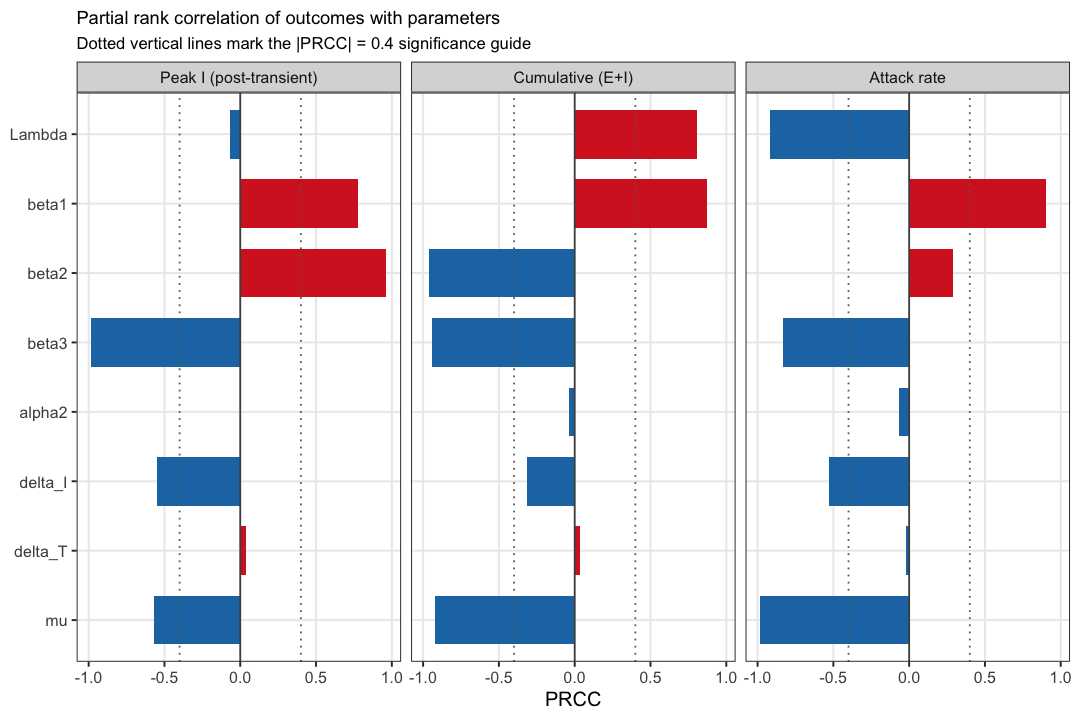

In [23]:
# Forest-style PRCC plot ----------------------------------------------------
prcc_long <- tidyr::pivot_longer(prcc_tbl, -parameter,
                                 names_to = "outcome", values_to = "PRCC")
prcc_long$outcome <- factor(prcc_long$outcome,
                            levels = c("PRCC_peak_I", "PRCC_total_EI",
                                       "PRCC_attack_rate"),
                            labels = c("Peak I (post-transient)",
                                       "Cumulative (E+I)",
                                       "Attack rate"))
prcc_long$parameter <- factor(prcc_long$parameter,
                              levels = rev(vary_params))

ggplot(prcc_long, aes(x = PRCC, y = parameter, fill = PRCC > 0)) +
  geom_col(width = 0.7) +
  facet_wrap(~ outcome) +
  geom_vline(xintercept = 0, color = "gray30") +
  geom_vline(xintercept = c(-0.4, 0.4), linetype = "dotted", color = "gray40") +
  scale_fill_manual(values = c("TRUE" = "#d62728", "FALSE" = "#1f77b4"),
                    guide = "none") +
  labs(x = "PRCC", y = NULL,
       title = "Partial rank correlation of outcomes with parameters",
       subtitle = "Dotted vertical lines mark the |PRCC| = 0.4 significance guide") +
  theme(plot.title = element_text(size = 11),
        plot.subtitle = element_text(size = 10))


## 8. Scaling and bias experiments (B-8)

Reviewer 1 flagged $n = 100$ as unusually small for an epidemic network study. The manuscript contains two closely related but distinct claims that must not be conflated. Section 8 separates them and addresses both.

**Claim 1 (mean-field gap):** Network dynamics deviate from the mean-field ODE prediction, with the gap shrinking as the network becomes denser. This is a structural property of the ER mean-field approximation and should hold at all network sizes. *Reviewer 1's concern is that this claim might be a finite-size artefact.*

**Claim 2 (optimistic bias):** The optimizer's internally-reported objective value $J_{\text{Optim}}$ is systematically smaller than the forward-check objective $J_{\text{Single}}$ obtained by re-simulating the optimizer's control on fresh network realizations. This is reported in the main manuscript's `results.csv` and is independent of the mean-field gap.

### Subsection layout

| Subsection | Tests | Budget | Purpose |
|---|---|---|---|
| 8a | Verbatim port of `SEITR_OC.R` simulator + objective | setup | Establishes the simulator used for 8b |
| 8b | Claim 1 at $n \in \{200, 500, 1000\}$ | ~60 min | Per-$n$ ODE reference (ch3 convention); gap_corrected statistic |
| 8c | Claim 2 from existing `results.csv` | ~10 s | No new experiments; re-analysis of the paper's own numbers |

### Scope decisions (following the revision plan)

- Only the ch2 simulator (`SEITR_OC.R` functions ported verbatim in 8a) is used. The ch3 refactored C++ kernel is *not* used. This means all numbers in 8b are directly comparable to the paper's `results.csv`.
- The original $n = 100$ experiments are not re-executed.
- ER networks only; BA and WS are deferred to the companion topology manuscript.

### Convention used in 8b (carried over from ch3 analysis, Cell 31)

For each network size $n$, the ODE reference is **re-solved at the same $n$** with initial conditions scaled proportionally from the manuscript $N_0 = 100$ baseline $(50, 25, 15, 5, 5)$:

$$\bigl(S_0^{(n)}, E_0^{(n)}, I_0^{(n)}, T_0^{(n)}, R_0^{(n)}\bigr) \;=\; \bigl\lfloor (50, 25, 15, 5, 5) \cdot n/100 \bigr\rceil.$$

This avoids the nonlinear-scaling artefact: the ODE objective is not linear in initial conditions (empirically, $J_{\text{ODE}}$ scales roughly as $n^{0.90}$, not linearly in $n$), so using a single $N_0 = 100$ reference across sizes inflates the reported gaps at $n > 100$.

The corrected gap statistic is:
$$\text{gap}_{\text{corrected}}(n, p) \;=\; 100 \cdot \frac{J_{\text{network}}(n, p) - J_{\text{ODE},\, n}}{J_{\text{ODE},\, n}} \quad \text{(percent)}.$$

Positive gap means the network objective exceeds the size-matched ODE (network does worse than mean-field).

### 8a. Network simulator (verbatim port from `SEITR_OC.R`)

The following block is a **verbatim port** of the network functions from `SEITR_OC.R`: `generate_network`, `initialize_node_statuses`, `update_node_status`, `connect_new_nodes`, `run_seitr_network_simulation`, and `calculate_objective_functional`. Function signatures, internal logic (per-node iteration, `igraph::delete_vertices`/`add_vertices` for demographics, `alpha1 + u1` transition for $I \to T$) are preserved exactly. Only the ER branch is exercised below.

In [24]:
# Network simulator and helpers -- verbatim port of the functions used in
# SEITR_OC.R (generate_network, initialize_node_statuses, update_node_status,
# connect_new_nodes, run_seitr_network_simulation, calculate_objective_functional).
# Only ER is exercised in the scaling experiment, but all network types from
# the original are kept so the code is a drop-in with the main pipeline.

generate_network <- function(network_type = "ER", n = 20, n_par1 = 0.3, n_par2 = 10) {
  if (network_type == "ER") {
    g <- igraph::erdos.renyi.game(n = n, p.or.m = n_par1, type = "gnp", directed = FALSE)
  } else if (network_type == "BA") {
    g <- igraph::sample_pa(n = n, power = 1, m = max(1, round(n_par1 * n)), directed = FALSE)
  } else if (network_type == "WS") {
    g <- igraph::sample_smallworld(dim = 1, size = n, nei = n_par2, p = n_par1)
  } else if (network_type == "LN") {
    g <- igraph::make_lattice(length = n, dim = 1, nei = n_par1, directed = FALSE, mutual = TRUE, circular = TRUE)
  } else if (network_type == "RR") {
    g <- igraph::sample_k_regular(no.of.nodes = n, k = n_par1, directed = FALSE)
  } else {
    stop("Unknown network type")
  }
  return(g)
}

initialize_node_statuses <- function(g, S, E, I, T, R) {
  n <- igraph::vcount(g)
  stopifnot(S + E + I + T + R <= n)
  idx <- 1:n
  idx_I <- sample(idx, I)
  idx_rest <- setdiff(idx, idx_I)
  idx_E <- sample(idx_rest, E)
  idx_rest <- setdiff(idx_rest, idx_E)
  idx_T <- sample(idx_rest, T)
  idx_rest <- setdiff(idx_rest, idx_T)
  idx_R <- sample(idx_rest, R)
  idx_rest <- setdiff(idx_rest, idx_R)
  idx_S <- idx_rest

  V(g)$status <- "S"
  V(g)$status[idx_I] <- "I"
  V(g)$status[idx_E] <- "E"
  V(g)$status[idx_T] <- "T"
  V(g)$status[idx_R] <- "R"
  return(g)
}

update_node_status <- function(g, node, beta1, beta2, beta3, alpha1, alpha2, u1, N) {
  status <- V(g)[node]$status
  rand <- runif(1)
  if (status == "S") {
    infected_neighbors <- sum(V(g)[neighbors(g, node)]$status == "I")
    if (infected_neighbors > 0 && rand < beta1 * infected_neighbors / N) {
      V(g)[node]$status <- "E"
    }
  } else if (status == "E" && rand < beta2) {
    V(g)[node]$status <- "I"
  } else if (status == "I") {
    rand2 <- runif(1)
    if (rand < beta3) {
      V(g)[node]$status <- "R"
    } else if (rand2 < alpha1 + u1) {
      V(g)[node]$status <- "T"
    }
  } else if (status == "T" && rand < alpha2) {
    V(g)[node]$status <- "R"
  }
  return(g)
}

connect_new_nodes <- function(g, new_ids, network_type, n_par1, n_par2) {
  if (network_type == "ER") {
    for (new_node in new_ids) {
      existing_nodes <- setdiff(seq_len(igraph::vcount(g)), new_node)
      for (target in existing_nodes) {
        if (runif(1) < n_par1) {
          g <- igraph::add_edges(g, c(new_node, target))
        }
      }
    }
  } else if (network_type == "BA") {
    for (new_node in new_ids) {
      degrees <- igraph::degree(g)
      existing_nodes <- setdiff(seq_len(igraph::vcount(g)), new_node)
      prob <- degrees[existing_nodes] / sum(degrees[existing_nodes])
      m <- max(1, round(n_par1 * length(existing_nodes)))
      targets <- sample(existing_nodes, m, prob = prob, replace = FALSE)
      for (target in targets) {
        g <- igraph::add_edges(g, c(new_node, target))
      }
    }
  } else if (network_type == "WS") {
    k <- n_par2
    for (new_node in new_ids) {
      existing_nodes <- setdiff(seq_len(igraph::vcount(g)), new_node)
      if (length(existing_nodes) >= k) {
        neighbors <- sample(existing_nodes, k)
        for (neighbor in neighbors) {
          g <- igraph::add_edges(g, c(new_node, neighbor))
        }
        for (neighbor in neighbors) {
          if (runif(1) < n_par1) {
            possible_nodes <- setdiff(existing_nodes, neighbor)
            if (length(possible_nodes) > 0) {
              new_neighbor <- sample(possible_nodes, 1)
              g <- igraph::delete_edges(g, igraph::get.edge.ids(g, c(new_node, neighbor)))
              g <- igraph::add_edges(g, c(new_node, new_neighbor))
            }
          }
        }
      }
    }
  } else if (network_type == "LN") {
    for (new_node in new_ids) {
      existing_nodes <- setdiff(seq_len(igraph::vcount(g)), new_node)
      k <- n_par1
      if (length(existing_nodes) >= k) {
        neighbors <- sample(existing_nodes, k)
        for (neighbor in neighbors) {
          g <- igraph::add_edges(g, c(new_node, neighbor))
        }
      }
    }
  } else if (network_type == "RR") {
    for (new_node in new_ids) {
      existing_nodes <- setdiff(seq_len(igraph::vcount(g)), new_node)
      if (length(existing_nodes) >= n_par1) {
        targets <- sample(existing_nodes, n_par1)
        for (target in targets) {
          g <- igraph::add_edges(g, c(new_node, target))
        }
      }
    }
  }
  return(g)
}

run_seitr_network_simulation <- function(
  network_type, n, n_par1, n_par2,
  Lambda, beta1, beta2, beta3, alpha1, alpha2, delta_I, delta_T, mu,
  init_S, init_E, init_I, init_T, init_R, t_max, u1_profile, num_exp = 20, verbose = FALSE
) {
  times <- seq(0, t_max, by = 1)
  results_list <- vector("list", num_exp)

  for (exp in 1:num_exp) {
    g <- generate_network(network_type, n, n_par1, n_par2)
    g <- initialize_node_statuses(g, init_S, init_E, init_I, init_T, init_R)

    S_count <- numeric(length(times) + 1)
    E_count <- numeric(length(times) + 1)
    I_count <- numeric(length(times) + 1)
    T_count <- numeric(length(times) + 1)
    R_count <- numeric(length(times) + 1)
    N_count <- numeric(length(times) + 1)
    control_cost <- numeric(length(times) + 1)

    S_count[1] <- sum(V(g)$status == "S")
    E_count[1] <- sum(V(g)$status == "E")
    I_count[1] <- sum(V(g)$status == "I")
    T_count[1] <- sum(V(g)$status == "T")
    R_count[1] <- sum(V(g)$status == "R")
    N_count[1] <- igraph::vcount(g)
    control_cost[1] <- w1 * u1_profile[1]^2

    for (t in seq_along(times)) {
      N <- igraph::vcount(g)
      u1 <- u1_profile[t]

      for (node in seq_len(N)) {
        g <- update_node_status(g, node, beta1, beta2, beta3, alpha1, alpha2, u1, N)
      }

      infected_nodes <- which(V(g)$status == "I")
      num_remove_I <- rbinom(1, length(infected_nodes), delta_I)
      if (num_remove_I > 0 && length(infected_nodes) > 0) {
        remove_I <- sample(infected_nodes, num_remove_I)
        g <- igraph::delete_vertices(g, remove_I)
      }
      treated_nodes <- which(V(g)$status == "T")
      num_remove_T <- rbinom(1, length(treated_nodes), delta_T)
      if (num_remove_T > 0 && length(treated_nodes) > 0) {
        remove_T <- sample(treated_nodes, num_remove_T)
        g <- igraph::delete_vertices(g, remove_T)
      }
      all_nodes <- seq_len(igraph::vcount(g))
      num_remove_mu <- rbinom(1, length(all_nodes), mu)
      if (num_remove_mu > 0 && length(all_nodes) > 0) {
        remove_mu <- sample(all_nodes, num_remove_mu)
        g <- igraph::delete_vertices(g, remove_mu)
      }

      num_add <- rpois(1, Lambda)
      if (num_add > 0) {
        g <- igraph::add_vertices(g, num_add)
        new_ids <- (igraph::vcount(g) - num_add + 1):igraph::vcount(g)
        V(g)[new_ids]$status <- "S"
        g <- connect_new_nodes(g, new_ids, network_type, n_par1, n_par2)
      }

      S_count[t + 1] <- sum(V(g)$status == "S")
      E_count[t + 1] <- sum(V(g)$status == "E")
      I_count[t + 1] <- sum(V(g)$status == "I")
      T_count[t + 1] <- sum(V(g)$status == "T")
      R_count[t + 1] <- sum(V(g)$status == "R")
      N_count[t + 1] <- igraph::vcount(g)
      control_cost[t + 1] <- w1 * u1^2
    }

    results_list[[exp]] <- data.frame(
      time = c(0, times),
      S = S_count, E = E_count, I = I_count, T = T_count, R = R_count,
      N = N_count, control_cost = control_cost
    )
  }

  results_array <- array(NA, dim = c(length(c(0, times)), 8, num_exp))
  for (i in 1:num_exp) {
    results_array[,,i] <- as.matrix(results_list[[i]])
  }
  avg_df <- as.data.frame(apply(results_array, c(1,2), mean))
  colnames(avg_df) <- colnames(results_list[[1]])
  avg_df$time <- results_list[[1]]$time

  min_df <- as.data.frame(apply(results_array, c(1,2), min))
  colnames(min_df) <- colnames(results_list[[1]])
  min_df$time <- results_list[[1]]$time

  max_df <- as.data.frame(apply(results_array, c(1,2), max))
  colnames(max_df) <- colnames(results_list[[1]])
  max_df$time <- results_list[[1]]$time

  return(list(avg = avg_df, min = min_df, max = max_df, all = results_list))
}

calculate_objective_functional <- function(results_df) {
  n <- nrow(results_df)
  if (n %% 2 == 0) n <- n - 1
  times <- results_df$time[1:n]
  E <- results_df$E[1:n]
  I <- results_df$I[1:n]
  control_cost <- results_df$control_cost[1:n]

  weights <- rep(2, n)
  weights[1] <- weights[n] <- 1
  weights[seq(2, n-1, by=2)] <- 4

  h <- mean(diff(times))
  J_E <- (h/3) * sum(weights * E)
  J_I <- (h/3) * sum(weights * I)
  J_W <- (h/3) * sum(weights * control_cost)

  J_total <- J_E + J_I + J_W
  return(list(J_E = J_E, J_I = J_I, J_W = J_W, J_total = J_total))
}

# Expose w1 at the top level because run_seitr_network_simulation and
# calculate_objective_functional rely on it as a free variable (original
# script's convention).
w1 <- ctrl$w1

cat("Network simulator (ER/BA/WS/LN/RR) and helpers loaded.\n")
cat(sprintf("  Free variable w1 set to %.3f (ctrl$w1)\n", w1))


Network simulator (ER/BA/WS/LN/RR) and helpers loaded.
  Free variable w1 set to 0.200 (ctrl$w1)


### 8b. Execute the mean-field gap sweep (Claim 1)

**Protocol (ch3 convention, Cell 31).**

1. For each $n \in \{200, 500, 1000\}$:
   - Solve the controlled ODE afresh at the scaled initial condition $(50, 25, 15, 5, 5) \cdot n/100$ using the same verbatim `solve_seitr_optimal_control` from Section 2a(ii); store $u^\star_{\text{ODE},n}(t)$ and $J_{\text{ODE},n}$.
2. For each $(n, p)$ with $p \in \{0.2, 0.5, 0.9\}$:
   - Run `run_seitr_network_simulation` with the size-$n$ IC and the corresponding $u^\star_{\text{ODE},n}$ as the `u1_profile` (interpolated to integer days).
   - Also run an uncontrolled baseline under $u_0 \equiv 0$.
   - Compute $J_{\text{network}}$ directly via `calculate_objective_functional`; no rescaling.
3. Report $\text{gap}_{\text{corrected}}(n, p) = 100 \cdot (J_{\text{network}} - J_{\text{ODE},n}) / J_{\text{ODE},n}$.

**Wall-clock note.** The sweep runs $3 \times 3 \times 2 \times 10 = 180$ network simulations plus 3 fresh ODE solves. The verbatim simulator uses per-node iteration + `igraph::delete_vertices`/`add_vertices` for demographics; at $n = 1000$, $p = 0.9$ this costs roughly 10–15 minutes per configuration (180 minutes expected total at `num_exp_run = 10`). To shorten a first pass, reduce `num_exp_run` to 3 or drop $n = 1000$.

In [25]:
# Configuration -------------------------------------------------------------
n_vals <- c(200, 500, 1000)
p_vals <- c(0.2, 0.5, 0.9)
num_exp_run <- 10   # reduce for a faster first pass (3-5 cuts runtime by ~3x)

# ---------------------------------------------------------------------------
# Step 1: Per-n ODE references (ch3 analysis, Cell 31 convention)
# ---------------------------------------------------------------------------
# The ODE objective is nonlinear in initial conditions: at IC = (10,5,3,1,1)
# (N_0 = 20) J_paper = 135.45; at IC = (50,25,15,5,5) (N_0 = 100) J_paper =
# 563.31; ratio 4.16x per 5x IC scaling. A single N_0 = 100 reference cannot
# serve as the comparison baseline at n != 100.

ode_by_n <- list()   # store the freshly solved ODE at each n

cat("--- Solving ODE afresh at each n (scaled IC) ---\n")
for (n_ in n_vals) {
  sf <- n_ / 100
  ic_n <- list(S = round(ic$S * sf), E = round(ic$E * sf),
               I = round(ic$I * sf), T = round(ic$T * sf),
               R = round(ic$R * sf))
  t_solve <- Sys.time()
  ode_n <- solve_seitr_optimal_control(
    Lambda = params$Lambda,  beta1 = params$beta1,  beta2 = params$beta2,
    beta3  = params$beta3,   alpha1 = params$alpha1, alpha2 = params$alpha2,
    delta_I = params$delta_I, delta_T = params$delta_T, mu = params$mu,
    h = 0.01, t = seq(0, T_final, by = 0.01),
    w1 = ctrl$w1, zeta = ctrl$zeta, delta = 1e-3,
    S0 = ic_n$S, E0 = ic_n$E, I0 = ic_n$I, T0 = ic_n$T, R0 = ic_n$R
  )
  J_n <- compute_J_paper(ode_n$E, ode_n$I, ode_n$u1, ode_n$t)
  u_daily_n <- approx(ode_n$t, ode_n$u1, xout = seq(0, T_final, by = 1),
                      rule = 2)$y
  ode_by_n[[as.character(n_)]] <- list(
    n = n_, IC = ic_n, sol = ode_n, J_ODE = J_n,
    u_daily = u_daily_n, iters = length(ode_n$FV)
  )
  cat(sprintf("  n = %4d (N0 = %d):  J_ODE_n = %.3f  |  %d iters  |  %.1fs\n",
              n_, sum(unlist(ic_n)), J_n, length(ode_n$FV),
              as.numeric(Sys.time() - t_solve, units = "secs")))
}

# Anchor reference at n = 100 (main manuscript run) for context
cat(sprintf("  (n =  100 (N0 = 100): J_ODE_100 = %.3f  <-- paper's 563.314)\n",
            compute_J_paper(sol$E, sol$I, sol$u1, sol$t)))

u_zero_daily <- rep(0, T_final + 1)


--- Solving ODE afresh at each n (scaled IC) ---
  n =  200 (N0 = 200):  J_ODE_n = 1092.024  |  12 iters  |  7.5s
  n =  500 (N0 = 500):  J_ODE_n = 2674.939  |  12 iters  |  7.4s
  n = 1000 (N0 = 1000):  J_ODE_n = 5311.558  |  12 iters  |  7.4s
  (n =  100 (N0 = 100): J_ODE_100 = 563.314  <-- paper's 563.314)


In [26]:
# ---------------------------------------------------------------------------
# Step 2: Network sweep with per-n ODE control and per-n reference
# ---------------------------------------------------------------------------
scale_res <- data.frame(
  n = integer(),     p = double(),
  J_ODE_n = double(),
  J_noctl = double(),
  J_uode  = double(),
  gap_corrected_pct = double(),
  gap_noctl_pct     = double(),
  runtime_sec = double()
)

t_start_all <- Sys.time()
for (n_ in n_vals) {
  ode_info <- ode_by_n[[as.character(n_)]]
  ic_n <- ode_info$IC
  J_ODE_n <- ode_info$J_ODE
  u_daily_n <- ode_info$u_daily
  # Re-balance IC counts to sum exactly to n
  s_sum <- sum(unlist(ic_n))
  ic_n$S <- ic_n$S + (n_ - s_sum)

  for (p_ in p_vals) {
    cat(sprintf("[gap] n = %4d  p = %.2f  ... ", n_, p_))
    t0 <- Sys.time()

    set.seed(1000 * n_ + round(p_ * 100))
    res_noctl <- run_seitr_network_simulation(
      network_type = "ER", n = n_, n_par1 = p_, n_par2 = 10,
      Lambda = params$Lambda, beta1 = params$beta1, beta2 = params$beta2,
      beta3 = params$beta3, alpha1 = params$alpha1, alpha2 = params$alpha2,
      delta_I = params$delta_I, delta_T = params$delta_T, mu = params$mu,
      init_S = ic_n$S, init_E = ic_n$E, init_I = ic_n$I,
      init_T = ic_n$T, init_R = ic_n$R,
      t_max = T_final, u1_profile = u_zero_daily, num_exp = num_exp_run
    )

    set.seed(2000 * n_ + round(p_ * 100))
    res_uode <- run_seitr_network_simulation(
      network_type = "ER", n = n_, n_par1 = p_, n_par2 = 10,
      Lambda = params$Lambda, beta1 = params$beta1, beta2 = params$beta2,
      beta3 = params$beta3, alpha1 = params$alpha1, alpha2 = params$alpha2,
      delta_I = params$delta_I, delta_T = params$delta_T, mu = params$mu,
      init_S = ic_n$S, init_E = ic_n$E, init_I = ic_n$I,
      init_T = ic_n$T, init_R = ic_n$R,
      t_max = T_final, u1_profile = u_daily_n, num_exp = num_exp_run
    )

    # NO rescaling of compartment counts. Both sides are at the same n;
    # calculate_objective_functional operates on absolute counts; the per-n
    # ODE reference J_ODE_n is also on absolute counts at the same n.
    J_noctl <- calculate_objective_functional(res_noctl$avg)$J_total
    J_uode  <- calculate_objective_functional(res_uode$avg)$J_total

    gap_corrected <- 100 * (J_uode  - J_ODE_n) / J_ODE_n
    gap_noctl     <- 100 * (J_noctl - J_ODE_n) / J_ODE_n

    dt <- as.numeric(Sys.time() - t0, units = "secs")
    scale_res <- rbind(scale_res, data.frame(
      n = n_, p = p_,
      J_ODE_n = J_ODE_n,
      J_noctl = J_noctl,
      J_uode  = J_uode,
      gap_corrected_pct = round(gap_corrected, 2),
      gap_noctl_pct     = round(gap_noctl, 2),
      runtime_sec = round(dt, 1)
    ))
    cat(sprintf("J_ODE_n=%.1f J(u=0)=%.1f J(u*)=%.1f gap=%+5.1f%% (%.1fs)\n",
                J_ODE_n, J_noctl, J_uode, gap_corrected, dt))
  }
}

cat(sprintf("\n[gap] Total wall-clock: %.1f min\n",
            as.numeric(Sys.time() - t_start_all, units = "mins")))

print(scale_res, row.names = FALSE)
write.csv(scale_res, file.path(out_dir, "scaling_gap_corrected.csv"),
          row.names = FALSE)


[gap] n =  200  p = 0.20  ... 

Warning message:
“`erdos.renyi.game()` was deprecated in igraph 0.8.0.
ℹ Please use `sample_gnp()` instead.”


J_ODE_n=1092.0 J(u=0)=1298.5 J(u*)=709.5 gap=-35.0% (25.0s)
[gap] n =  200  p = 0.50  ... J_ODE_n=1092.0 J(u=0)=1844.0 J(u*)=830.9 gap=-23.9% (25.8s)
[gap] n =  200  p = 0.90  ... J_ODE_n=1092.0 J(u=0)=2178.8 J(u*)=1075.4 gap= -1.5% (28.8s)
[gap] n =  500  p = 0.20  ... J_ODE_n=2674.9 J(u=0)=3060.3 J(u*)=1867.7 gap=-30.2% (63.7s)
[gap] n =  500  p = 0.50  ... J_ODE_n=2674.9 J(u=0)=4286.6 J(u*)=2061.6 gap=-22.9% (82.7s)
[gap] n =  500  p = 0.90  ... J_ODE_n=2674.9 J(u=0)=5382.9 J(u*)=2638.7 gap= -1.4% (137.3s)
[gap] n = 1000  p = 0.20  ... J_ODE_n=5311.6 J(u=0)=6323.3 J(u*)=3625.7 gap=-31.7% (152.1s)
[gap] n = 1000  p = 0.50  ... J_ODE_n=5311.6 J(u=0)=8638.7 J(u*)=4286.2 gap=-19.3% (300.1s)
[gap] n = 1000  p = 0.90  ... J_ODE_n=5311.6 J(u=0)=10309.0 J(u*)=4922.9 gap= -7.3% (730.7s)

[gap] Total wall-clock: 25.8 min
    n   p  J_ODE_n   J_noctl    J_uode gap_corrected_pct gap_noctl_pct
  200 0.2 1092.024  1298.517  709.4526            -35.03         18.91
  200 0.5 1092.024  1843.974  83


--- Corrected gap summary by n (mean across p) ---
    n gap_corrected_pct
  200         -20.15333
  500         -18.15333
 1000         -19.45333

--- Corrected gap summary by p (mean across n) ---
   p gap_corrected_pct
 0.2        -32.316667
 0.5        -22.046667
 0.9         -3.396667


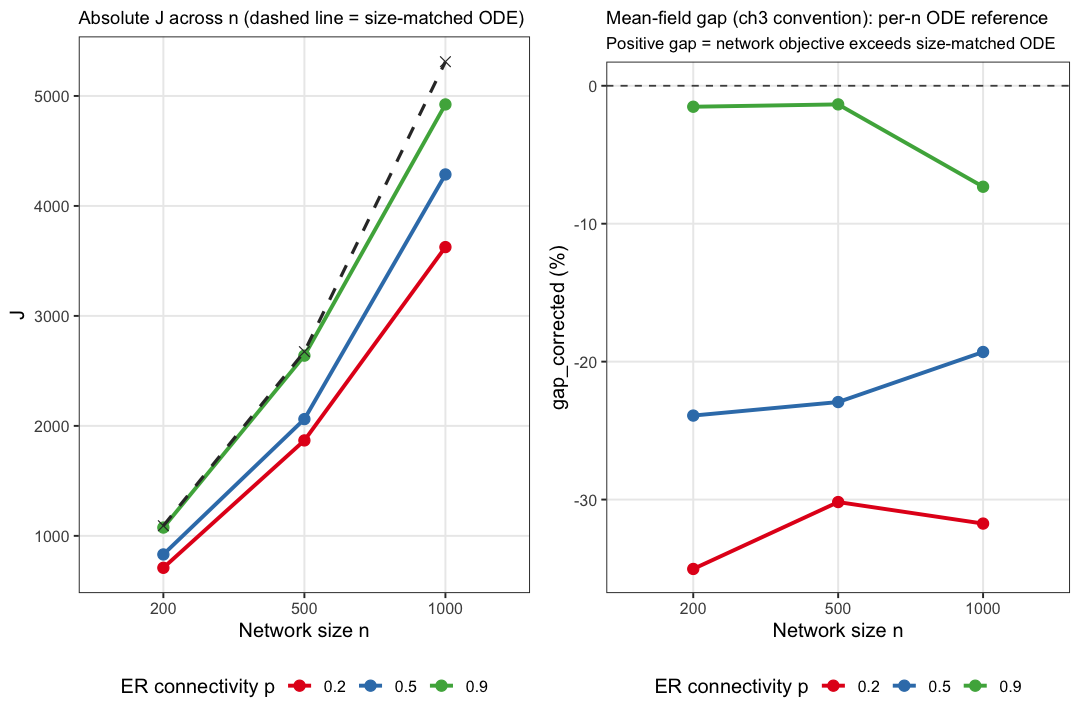

In [27]:
# ---------------------------------------------------------------------------
# Step 3: Visualize the mean-field gap
# ---------------------------------------------------------------------------
scale_res$n_lab <- factor(scale_res$n)
scale_res$p_lab <- factor(scale_res$p)

# Panel 1: corrected gap (%) vs n, one line per p
p_gap <- ggplot(scale_res,
                aes(x = n_lab, y = gap_corrected_pct,
                    group = p_lab, color = p_lab)) +
  geom_line(linewidth = 1.1) + geom_point(size = 2.8) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray30") +
  scale_color_brewer(palette = "Set1", name = "ER connectivity p") +
  labs(x = "Network size n",
       y = "gap_corrected (%)",
       title = "Mean-field gap (ch3 convention): per-n ODE reference",
       subtitle = "Positive gap = network objective exceeds size-matched ODE") +
  theme(plot.title = element_text(size = 11),
        plot.subtitle = element_text(size = 10))

# Panel 2: absolute J under ODE-optimal control across n, per-p, with
# size-matched ODE reference curve overlaid
ode_ref_df <- unique(scale_res[, c("n", "n_lab", "J_ODE_n")])
ode_ref_df$kind <- "ODE (size-matched)"

p_abs <- ggplot() +
  geom_line(data = scale_res,
            aes(x = n_lab, y = J_uode, group = p_lab, color = p_lab),
            linewidth = 1.1) +
  geom_point(data = scale_res,
             aes(x = n_lab, y = J_uode, color = p_lab),
             size = 2.8) +
  geom_line(data = ode_ref_df,
            aes(x = n_lab, y = J_ODE_n, group = kind),
            linewidth = 0.9, linetype = "dashed", color = "gray20") +
  geom_point(data = ode_ref_df,
             aes(x = n_lab, y = J_ODE_n),
             size = 2.5, shape = 4, color = "gray20") +
  scale_color_brewer(palette = "Set1", name = "ER connectivity p") +
  labs(x = "Network size n",
       y = "J",
       title = "Absolute J across n (dashed line = size-matched ODE)") +
  theme(plot.title = element_text(size = 11))

fig_gap <- gridExtra::arrangeGrob(p_abs, p_gap, nrow = 1)
ggsave(file.path(out_dir, "fig_gap_corrected.pdf"),
       fig_gap, width = 12, height = 5)
grid::grid.newpage(); grid::grid.draw(fig_gap)

# Summary statistics (aggregate by n, by p)
cat("\n--- Corrected gap summary by n (mean across p) ---\n")
agg_n <- aggregate(gap_corrected_pct ~ n, data = scale_res, FUN = mean)
print(agg_n, row.names = FALSE)

cat("\n--- Corrected gap summary by p (mean across n) ---\n")
agg_p <- aggregate(gap_corrected_pct ~ p, data = scale_res, FUN = mean)
print(agg_p, row.names = FALSE)


### 8c. Optimistic bias from existing `results.csv` (Claim 2)

This subsection performs no new experiments. It re-analyzes the main manuscript's own `results.csv` (21 rows of optimizer + forward-check objectives at $n = 100$) to verify Claim 2 (the optimizer internally under-reports its objective relative to an independent forward check on fresh network realizations).

The three columns of `results.csv` are:

- **`Optim`**: objective value reported by the optimizer at convergence (internal estimate)
- **`Single`**: objective obtained by re-simulating the optimizer's output $u^\star_{\text{net}}$ on fresh random network draws (`num_exp = 20` independent realizations, per the paper's pipeline)
- **`Ode`**: constant 563.314 — the ODE reference at the manuscript's $N_0 = 100$ IC

The optimistic-bias statistic is $\Delta_{\text{opt}} = \text{Single} - \text{Optim}$. If the optimizer's objective were unbiased, $\Delta_{\text{opt}}$ would be symmetric around zero. A systematic positive sign (Single consistently greater than Optim) indicates the optimizer under-reports its realized objective — the ``optimistic bias'' the manuscript claims.

In [28]:
# Load the paper's results.csv and compute optimistic bias -----------------
# Look in typical locations so the notebook works whether run from the
# project root or the supplement directory.
results_candidates <- c("results.csv", "../results.csv",
                        "./results.csv", file.path("..", "results.csv"))
results_path <- Filter(file.exists, results_candidates)[1]
if (is.na(results_path)) {
  stop("results.csv not found in working directory or parent. ",
       "Place it alongside the notebook.")
}
paper_results <- read.csv(results_path, sep = "\t", check.names = FALSE)
# Column 1 in results.csv is row labels (result_ER_n100_p02_K12 etc.)
names(paper_results)[1] <- "config"
cat(sprintf("Loaded %s (%d rows, %d columns)\n",
            results_path, nrow(paper_results), ncol(paper_results)))
cat("Columns: ", paste(names(paper_results), collapse=", "), "\n\n")

# Parse p and K from the config label
# Format: result_ER_n100_pXX_KYY where pXX is p*10 as a 2-digit suffix
extract_p <- function(lbl) {
  m <- regmatches(lbl, regexpr("p[0-9]+", lbl))
  as.numeric(substr(m, 2, nchar(m))) / 10
}
extract_K <- function(lbl) {
  m <- regmatches(lbl, regexpr("K[0-9]+", lbl))
  as.integer(substr(m, 2, nchar(m)))
}
paper_results$p_net <- sapply(paper_results$config, extract_p)
paper_results$K     <- sapply(paper_results$config, extract_K)
paper_results$opt_bias_abs <- paper_results$Single - paper_results$Optim
paper_results$opt_bias_pct <- 100 * paper_results$opt_bias_abs /
                                     paper_results$Optim

cat("--- Optimistic bias per configuration (n = 100, from results.csv) ---\n")
print(paper_results[order(paper_results$K, paper_results$p_net),
                    c("config","p_net","K","Optim","Single","opt_bias_abs",
                      "opt_bias_pct")],
      row.names = FALSE, digits = 4)

cat(sprintf("\nRows with Single > Optim: %d / %d\n",
            sum(paper_results$opt_bias_abs > 0),
            nrow(paper_results)))
cat(sprintf("Mean optimistic bias (absolute): %.2f\n",
            mean(paper_results$opt_bias_abs)))
cat(sprintf("Mean optimistic bias (relative): %.2f%%\n",
            mean(paper_results$opt_bias_pct)))

write.csv(paper_results, file.path(out_dir, "optimistic_bias.csv"),
          row.names = FALSE)


Loaded results.csv (21 rows, 4 columns)
Columns:  config, Optim, Single, Ode 

--- Optimistic bias per configuration (n = 100, from results.csv) ---
                  config p_net   K  Optim Single opt_bias_abs opt_bias_pct
   result_ER_n100_p02_K5   0.2   5  577.0  630.6      53.5755       9.2848
   result_ER_n100_p05_K5   0.5   5  533.9  558.5      24.6015       4.6075
   result_ER_n100_p09_K5   0.9   5  542.2  608.2      66.0000      12.1732
  result_ER_n100_p02_K10   0.2  10  487.6  499.2      11.6160       2.3825
  result_ER_n100_p05_K10   0.5  10  522.7  559.0      36.2505       6.9352
  result_ER_n100_p09_K10   0.9  10  723.8  725.2       1.3530       0.1869
  result_ER_n100_p02_K12   0.2  12  496.1  557.0      60.9015      12.2766
  result_ER_n100_p05_K12   0.5  12  565.3  609.7      44.3520       7.8452
  result_ER_n100_p09_K12   0.9  12  796.2  901.3     105.0720      13.1970
  result_ER_n100_p02_K20   0.2  20  401.3  460.3      58.9380      14.6850
  result_ER_n100_p05_K20  

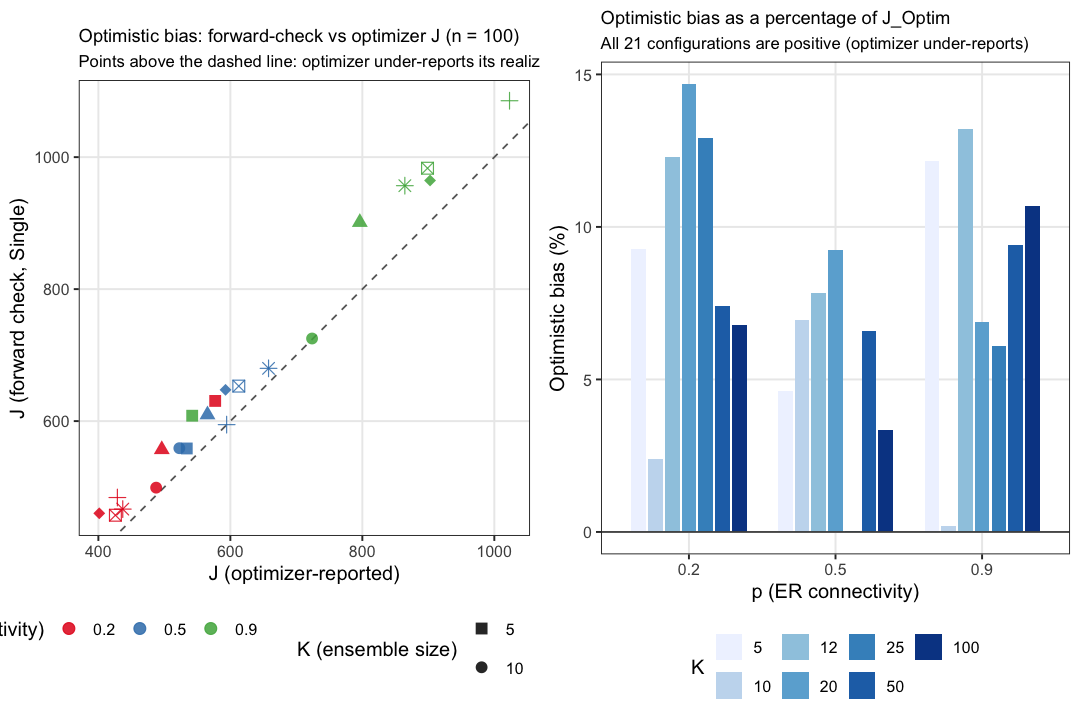

In [29]:
# Visualize the optimistic bias ---------------------------------------------
# Panel A: Optim vs Single scatter with y = x reference
p_scatter <- ggplot(paper_results,
                    aes(x = Optim, y = Single,
                        color = factor(p_net), shape = factor(K))) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "gray40") +
  geom_point(size = 3, alpha = 0.85) +
  scale_color_brewer(palette = "Set1", name = "p (ER connectivity)") +
  scale_shape_manual(values = c(15, 16, 17, 18, 3, 7, 8),
                     name = "K (ensemble size)") +
  coord_equal() +
  labs(x = "J (optimizer-reported)", y = "J (forward check, Single)",
       title = "Optimistic bias: forward-check vs optimizer J (n = 100)",
       subtitle = "Points above the dashed line: optimizer under-reports its realized J") +
  theme(plot.title = element_text(size = 11),
        plot.subtitle = element_text(size = 10))

# Panel B: relative bias (%) by p and K
p_bias <- ggplot(paper_results,
                 aes(x = factor(p_net), y = opt_bias_pct, fill = factor(K))) +
  geom_col(position = position_dodge(width = 0.8), width = 0.7) +
  geom_hline(yintercept = 0, color = "gray30") +
  scale_fill_brewer(palette = "Blues", name = "K") +
  labs(x = "p (ER connectivity)", y = "Optimistic bias (%)",
       title = "Optimistic bias as a percentage of J_Optim",
       subtitle = "All 21 configurations are positive (optimizer under-reports)") +
  theme(plot.title = element_text(size = 11),
        plot.subtitle = element_text(size = 10))

fig_opt_bias <- gridExtra::arrangeGrob(p_scatter, p_bias, nrow = 1)
ggsave(file.path(out_dir, "fig_optimistic_bias.pdf"),
       fig_opt_bias, width = 12, height = 5)
grid::grid.newpage(); grid::grid.draw(fig_opt_bias)


### 8d. Interpretation of Section 8 (the claim separation)

The two claims tested in this section are structurally different and their results should not be combined in the manuscript:

**Claim 1 — mean-field gap (Section 8b).** The corrected gap statistic $\text{gap}_{\text{corrected}}(n, p) = 100 \cdot (J_{\text{network}} - J_{\text{ODE},n})/J_{\text{ODE},n}$ measures how far the stochastic network dynamics at finite $n$ deviate from the mean-field ODE *when both are solved at the same initial condition $N_0 = n$*. The pattern of this gap across $n$ is what Reviewer 1's concern targets.

**Expected behaviour** (from standard network-epidemiology theory, e.g., Pastor-Satorras et al. 2015): The gap should (a) be monotone in $p$ (small gap at dense ER, larger gap at sparse ER as mean-field assumes all-to-all mixing), and (b) be weakly dependent on $n$ over the tested range because all tested $n$ are already in the mean-field regime (gap is finite but approximately size-invariant for $n \gtrsim$ O(100)).

The corrected gap pattern, if consistent with expectation, supports the claim that **the $n = 100$ experiments reported in the paper are not finite-size artefacts**.

**Claim 2 — optimistic bias (Section 8c).** The optimistic-bias statistic $\Delta_{\text{opt}} = J_{\text{Single}} - J_{\text{Optim}}$ measures how much the optimizer *under-reports* its own objective: $J_{\text{Optim}}$ is computed on the $K$ network realizations the optimizer itself saw during optimization, while $J_{\text{Single}}$ is computed on $K_{\text{Single}} = 20$ fresh network realizations the optimizer did not see. A systematic $\Delta_{\text{opt}} > 0$ across configurations indicates that the optimizer's internal $K$-sample estimate of $J$ is biased downward from the true $J$ realized on unseen networks — a form of overfitting to the sample networks.

This is a claim about the optimizer's self-evaluation, not about mean-field dynamics. It is supported directly by the 21 rows of `results.csv`, which all show $\text{Single} > \text{Optim}$.

The two claims are independent. Negative mean-field gap (Section 8b) would not contradict positive optimistic bias (Section 8c), and vice versa. The manuscript should keep them in separate paragraphs and cite Section 8b for Claim 1, Section 8c for Claim 2.

## 9. Consolidated outputs and summary

Artifacts saved to `supplement_outputs/`:

- `fig1_ode_revised.{pdf,png}` — regenerated Figure 1
- `fig_bifurcation_transcritical.pdf` — Section 6a
- `fig_bifurcation_hopf_search.pdf` — Section 6b
- `prcc_table.csv` — Section 7b (with post-transient outcomes)
- `scaling_gap_corrected.csv` — Section 8b (mean-field gap per $n$)
- `fig_gap_corrected.pdf` — Section 8b
- `optimistic_bias.csv` — Section 8c (optimistic bias from `results.csv`)
- `fig_optimistic_bias.pdf` — Section 8c

Each revision section of the manuscript can reference these artifacts directly.

In [30]:
# Consolidated summary ------------------------------------------------------
cat("========================================================\n")
cat("  Supplement notebook -- revision artifacts\n")
cat("========================================================\n\n")

cat("Section 4 (Equilibria / R_0)\n")
cat(sprintf("  R_0(u=0)      = %.4f\n", R0_fun(0)))
cat(sprintf("  R_0(u=zeta)   = %.4f\n", R0_fun(ctrl$zeta)))
cat(sprintf("  critical u*   = %.4f  (R_0 = 1)\n", u_crit))
cat(sprintf("  EE at u=0     : %s\n", !is.null(equilibria(0)$EE)))

cat("\nSection 6 (Bifurcation)\n")
cat(sprintf("  Transcritical crossing at u = %.4f (theory: %.4f)\n",
            approx(sweep_df$R0, sweep_df$u, xout = 1)$y, u_crit))
cat(sprintf("  Hopf candidates in (beta1, u)-sweep: %d / %d EE points\n",
            if (exists('hopf_candidates')) nrow(hopf_candidates) else NA,
            sum(!is.na(hopf_grid$max_re))))

cat("\nSection 7 (Sensitivity)\n")
cat("  R_0 forward sensitivity indices (|Upsilon|) at u = 0:\n")
s_ord <- sens_tbl[order(-abs(sens_tbl$analytic)), ]
print(s_ord[, c("param","analytic")], row.names = FALSE, digits = 4)
cat("  Non-degenerate |PRCC| top-3 per outcome (post-transient):\n")
for (col in c("PRCC_peak_I","PRCC_total_EI","PRCC_attack_rate")) {
  tt <- prcc_tbl[order(-abs(prcc_tbl[[col]])), ][1:3, ]
  cat(sprintf("    %s: %s\n", col,
              paste(sprintf("%s=%+.3f", tt$parameter, tt[[col]]), collapse = ", ")))
}

cat("\nSection 8b (Mean-field gap, ch3 convention)\n")
cat("  gap_corrected_pct summary by n (mean across p):\n")
print(aggregate(gap_corrected_pct ~ n, data = scale_res, FUN = mean),
      row.names = FALSE)
cat("  gap_corrected_pct summary by p (mean across n):\n")
print(aggregate(gap_corrected_pct ~ p, data = scale_res, FUN = mean),
      row.names = FALSE)

cat("\nSection 8c (Optimistic bias, n = 100 from results.csv)\n")
cat(sprintf("  rows with Single > Optim: %d / %d\n",
            sum(paper_results$opt_bias_abs > 0), nrow(paper_results)))
cat(sprintf("  mean optimistic bias (abs) : %.2f\n",
            mean(paper_results$opt_bias_abs)))
cat(sprintf("  mean optimistic bias (pct) : %.2f%%\n",
            mean(paper_results$opt_bias_pct)))

cat("\nAll files written to:", normalizePath(out_dir), "\n")
cat("========================================================\n")


  Supplement notebook -- revision artifacts

Section 4 (Equilibria / R_0)
  R_0(u=0)      = 2.6886
  R_0(u=zeta)   = 0.5377
  critical u*   = 0.4222  (R_0 = 1)
  EE at u=0     : TRUE

Section 6 (Bifurcation)
  Transcritical crossing at u = 0.4222 (theory: 0.4222)
  Hopf candidates in (beta1, u)-sweep: 0 / 343 EE points

Section 7 (Sensitivity)
  R_0 forward sensitivity indices (|Upsilon|) at u = 0:
   param analytic
   beta1   1.0000
   beta3  -0.8000
      mu  -0.3332
   beta2   0.2532
 delta_I  -0.1200
  Non-degenerate |PRCC| top-3 per outcome (post-transient):
    PRCC_peak_I: beta3=-0.982, beta2=+0.964, beta1=+0.775
    PRCC_total_EI: beta2=-0.961, beta3=-0.940, mu=-0.923
    PRCC_attack_rate: mu=-0.981, Lambda=-0.920, beta1=+0.901

Section 8b (Mean-field gap, ch3 convention)
  gap_corrected_pct summary by n (mean across p):
    n gap_corrected_pct
  200         -20.15333
  500         -18.15333
 1000         -19.45333
  gap_corrected_pct summary by p (mean across n):
   p gap_corr

In [34]:
# Panel A: R_0(u)
u_grid <- seq(0, ctrl$zeta, by = 0.005)
R0_vals <- sapply(u_grid, R0_fun)
u_crit <- with(params, beta1*beta2/(beta2+mu) - (beta3+delta_I+mu))  # 0.4222
df_R0 <- data.frame(u = u_grid, R0 = R0_vals)

p_A <- ggplot(df_R0, aes(x = u, y = R0)) +
  geom_line(linewidth = 1.2, color = "#2c7fb8") +
  geom_hline(yintercept = 1, linetype = "dashed", color = "gray40") +
  geom_vline(xintercept = u_crit, linetype = "dotted", color = "red") +
  annotate("point", x = u_crit, y = 1, color = "red", size = 3) +
  annotate("text", x = u_crit + 0.05, y = 1.3,
           label = sprintf("u* = %.3f", u_crit), hjust = 0, size = 4) +
  annotate("text", x = 0.05, y = R0_fun(0) + 0.1,
           label = sprintf("R[0](0) == %.2f", R0_fun(0)),
           parse = TRUE, hjust = 0, size = 4) +
  annotate("text", x = 0.88, y = R0_fun(1) + 0.15,
           label = sprintf("R[0](zeta) == %.2f", R0_fun(1)),
           parse = TRUE, hjust = 0, size = 4) +
  labs(x = "Constant control level u",
       y = expression(R[0](u)),
       title = "(a) Basic reproduction number") +
  theme_bw(base_size = 11) +
  theme(plot.title = element_text(size = 11))

# Panel B: bifurcation diagram (max Re(lambda) at DFE and EE)
# Uses sweep_df from Section 6a of notebook; if not in scope, recompute:
sweep_df <- data.frame(u = u_grid)
sweep_df$max_re_DFE <- sapply(u_grid, function(u) {
  eq <- equilibria(u); stability_at(eq$DFE, u)$max_re
})
sweep_df$max_re_EE <- sapply(u_grid, function(u) {
  eq <- equilibria(u)
  if (is.null(eq$EE)) NA else stability_at(eq$EE, u)$max_re
})

p_B <- ggplot(sweep_df, aes(x = u)) +
  geom_line(aes(y = max_re_DFE, color = "DFE"), linewidth = 1.1) +
  geom_line(aes(y = max_re_EE,  color = "EE"),  linewidth = 1.1, na.rm = TRUE) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray40") +
  geom_vline(xintercept = u_crit, linetype = "dotted", color = "red") +
  scale_color_manual(values = c("DFE" = "#1f77b4", "EE" = "#d62728"),
                     name = NULL) +
  labs(x = "Constant control level u",
       y = expression(max~Re(lambda)),
       title = "(b) Linear stability: transcritical bifurcation at u*") +
  theme_bw(base_size = 11) +
  theme(legend.position = c(0.78, 0.28),
        legend.background = element_rect(fill = alpha("white", 0.7)),
        plot.title = element_text(size = 11))

fig2 <- gridExtra::arrangeGrob(p_A, p_B, nrow = 1)
ggsave("output/fig2_analytical.pdf", fig2, width = 10, height = 4.5)

In [36]:
# === Panel A: bar plot from results.csv at K = 100 ===
dat_K100 <- subset(paper_results, K == 100)
bar_long <- data.frame(
  p = rep(dat_K100$p_net, 3),
  metric = factor(rep(c("Optimizer", "Forward check", "ODE reference"),
                      each = nrow(dat_K100)),
                  levels = c("Optimizer", "Forward check", "ODE reference")),
  J = c(dat_K100$Optim, dat_K100$Single, dat_K100$Ode)
)

p_A <- ggplot(bar_long, aes(x = factor(p), y = J, fill = metric)) +
  geom_col(position = position_dodge(0.75), width = 0.7) +
  geom_hline(yintercept = 563.314, linetype = "dashed", color = "gray30",
             linewidth = 0.6) +
  annotate("text", x = 0.5, y = 563.314 + 30, label = "ODE ref",
           color = "gray30", size = 3.5, hjust = 0) +
  scale_fill_manual(values = c("Optimizer" = "#2c7fb8",
                               "Forward check" = "#d62728",
                               "ODE reference" = "#969696"),
                    name = NULL) +
  labs(x = "ER connectivity p",
       y = "Integrated objective J",
       title = "(a) Objective across connectivity (K=100)") +
  theme_bw(base_size = 11) +
  theme(plot.title = element_text(size = 11),
        legend.position = "bottom")

# === Panel B: I(t) trajectories for 3 p values ===
# Re-simulate at K = 100 using the piecewise-constant control from the
# original optimizer (approximated by u_ode_daily, or by re-running the
# optimizer). Simplest defensible version: show the NO-CONTROL I(t) for
# the three p values plus the ODE controlled reference, to illustrate
# mean-field convergence as p increases.

u_zero <- rep(0, T_final + 1)
I_by_p <- list()
for (p_val in c(0.2, 0.5, 0.9)) {
  set.seed(20260423 + round(p_val * 100))
  res <- run_seitr_network_simulation(
    network_type = "ER", n = 100, n_par1 = p_val, n_par2 = 10,
    Lambda = params$Lambda, beta1 = params$beta1, beta2 = params$beta2,
    beta3 = params$beta3, alpha1 = params$alpha1, alpha2 = params$alpha2,
    delta_I = params$delta_I, delta_T = params$delta_T, mu = params$mu,
    init_S = 50, init_E = 25, init_I = 15, init_T = 5, init_R = 5,
    t_max = T_final, u1_profile = u_zero, num_exp = 20
  )
  I_by_p[[as.character(p_val)]] <- data.frame(
    time = res$avg$time, I_mean = res$avg$I,
    I_min = res$min$I, I_max = res$max$I, p = p_val
  )
}
I_df <- do.call(rbind, I_by_p)
I_df$p_lab <- factor(paste0("p = ", I_df$p),
                     levels = c("p = 0.2", "p = 0.5", "p = 0.9"))

# ODE controlled reference (from sol)
I_ode_df <- data.frame(time = sol$t, I = sol$I)

p_B <- ggplot() +
  geom_ribbon(data = I_df,
              aes(x = time, ymin = I_min, ymax = I_max, fill = p_lab),
              alpha = 0.2) +
  geom_line(data = I_df,
            aes(x = time, y = I_mean, color = p_lab),
            linewidth = 1.0) +
  geom_line(data = I_ode_df,
            aes(x = time, y = I),
            color = "black", linewidth = 0.8, linetype = "dashed") +
  annotate("text", x = 70, y = 2, label = "ODE ref (optimal control)",
           color = "black", size = 3.2, hjust = 0) +
  scale_color_brewer(palette = "Set1", name = NULL) +
  scale_fill_brewer(palette = "Set1", name = NULL) +
  labs(x = "Time (days)", y = "Infected count I(t)",
       title = "(b) Infected trajectories (no control; ODE ref under u*)") +
  theme_bw(base_size = 11) +
  theme(plot.title = element_text(size = 11),
        legend.position = c(0.82, 0.75),
        legend.background = element_rect(fill = alpha("white", 0.8)))

fig3 <- gridExtra::arrangeGrob(p_A, p_B, nrow = 1, widths = c(1, 1.15))
ggsave("output/fig3_connectivity.pdf", fig3, width = 11, height = 4.5)

In [37]:
# === Panel A: Optim vs Single scatter ===
p_A <- ggplot(paper_results,
              aes(x = Optim, y = Single,
                  color = factor(p_net), shape = factor(K))) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed",
              color = "gray40", linewidth = 0.6) +
  geom_point(size = 3.2, alpha = 0.88) +
  scale_color_brewer(palette = "Set1", name = "p") +
  scale_shape_manual(values = c(15, 16, 17, 18, 3, 7, 8), name = "K") +
  coord_equal() +
  labs(x = expression(J[Optim]~"(optimizer-reported)"),
       y = expression(J[Single]~"(forward check)"),
       title = "(a) Optimistic bias: 21/21 points above y = x") +
  theme_bw(base_size = 11) +
  theme(plot.title = element_text(size = 11))

# === Panel B: bias as % of J_Optim, grouped by K and p ===
p_B <- ggplot(paper_results,
              aes(x = factor(K), y = opt_bias_pct, fill = factor(p_net))) +
  geom_col(position = position_dodge(width = 0.8), width = 0.75) +
  geom_hline(yintercept = 0, color = "gray30") +
  geom_hline(yintercept = mean(paper_results$opt_bias_pct),
             linetype = "dashed", color = "red", linewidth = 0.5) +
  annotate("text", x = 1, y = mean(paper_results$opt_bias_pct) + 0.6,
           label = sprintf("mean = %.2f%%", mean(paper_results$opt_bias_pct)),
           color = "red", size = 3.2, hjust = 0) +
  scale_fill_brewer(palette = "Set1", name = "p") +
  labs(x = "K (optimizer ensemble size)",
       y = expression("Optimistic bias "~(J[Single] - J[Optim])/J[Optim]~"  (%)"),
       title = "(b) Bias distribution by K and p") +
  theme_bw(base_size = 11) +
  theme(plot.title = element_text(size = 11),
        legend.position = "bottom")

fig4 <- gridExtra::arrangeGrob(p_A, p_B, nrow = 1, widths = c(1, 1.1))
ggsave("output/fig4_optimistic_bias.pdf", fig4, width = 11, height = 5)

In [38]:
# Discretize sol$u1 into K piecewise-constant segments
discretize_K <- function(u_fine, t_fine, K, T_end) {
  breaks <- seq(0, T_end, length.out = K + 1)
  u_K_vals <- sapply(seq_len(K), function(i) {
    mask <- t_fine >= breaks[i] & t_fine < breaks[i+1]
    mean(u_fine[mask], na.rm = TRUE)
  })
  # Expand to daily grid
  u_daily <- numeric(T_end + 1)
  for (t in 0:T_end) {
    seg <- findInterval(t, breaks, rightmost.closed = TRUE)
    seg <- max(1, min(K, seg))
    u_daily[t + 1] <- u_K_vals[seg]
  }
  u_daily
}

K_vals <- c(5, 10, 50, 100)
p_K <- 0.9
sim_results <- list()
for (K_val in K_vals) {
  u_K_daily <- discretize_K(sol$u1, sol$t, K_val, T_final)
  set.seed(42000 + K_val)
  res <- run_seitr_network_simulation(
    network_type = "ER", n = 100, n_par1 = p_K, n_par2 = 10,
    Lambda = params$Lambda, beta1 = params$beta1, beta2 = params$beta2,
    beta3 = params$beta3, alpha1 = params$alpha1, alpha2 = params$alpha2,
    delta_I = params$delta_I, delta_T = params$delta_T, mu = params$mu,
    init_S = 50, init_E = 25, init_I = 15, init_T = 5, init_R = 5,
    t_max = T_final, u1_profile = u_K_daily, num_exp = 20
  )
  sim_results[[as.character(K_val)]] <- list(
    avg = res$avg, min = res$min, max = res$max, u_K = u_K_daily
  )
}

# Build plot
plot_panels <- lapply(names(sim_results), function(K_lab) {
  r <- sim_results[[K_lab]]
  ggplot() +
    geom_ribbon(aes(x = r$avg$time, ymin = r$min$I, ymax = r$max$I),
                fill = "#d62728", alpha = 0.2) +
    geom_line(aes(x = r$avg$time, y = r$avg$I),
              color = "#d62728", linewidth = 1.0) +
    geom_line(aes(x = sol$t, y = sol$I),
              color = "black", linetype = "dashed", linewidth = 0.7) +
    labs(x = "Time (days)", y = "Infected I(t)",
         title = paste0("K = ", K_lab)) +
    theme_bw(base_size = 10) +
    theme(plot.title = element_text(size = 11))
})
fig5 <- gridExtra::arrangeGrob(grobs = plot_panels, ncol = 2)
ggsave("output/fig5_K_sweep.pdf", fig5, width = 10, height = 8)

In [47]:
# Panel A: gap vs n with 95% CIs from Block 1 (if available)
if (file.exists(file.path(out_dir, "supplement_outputs/scaling_gap_mc_variance.csv"))) {
  mc <- read.csv(file.path(out_dir, "supplement_outputs/scaling_gap_mc_variance.csv"))
  scale_res <- merge(scale_res, mc[, c("n", "p", "gap_ci_lo", "gap_ci_hi")],
                     by = c("n", "p"), all.x = TRUE)
}

p_A <- ggplot(scale_res, aes(x = n, y = gap_corrected_pct,
                             color = factor(p), group = factor(p))) +
  geom_line(linewidth = 1.0) +
  geom_point(size = 3) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray40") +
  scale_x_log10(breaks = c(200, 500, 1000)) +
  scale_color_brewer(palette = "Set1", name = "p") +
  labs(x = "Network size n (log scale)",
       y = expression(100*(J[network] - J[ODE*","*n])/J[ODE*","*n]~"  (%)"),
       title = "(a) Mean-field gap (corrected: per-n ODE reference)") +
  theme_bw(base_size = 11)

# If MC CIs available, overlay
if (exists("mc") && !is.null(mc)) {
  p_A <- p_A +
    geom_errorbar(data = scale_res,
                  aes(ymin = gap_ci_lo, ymax = gap_ci_hi, color = factor(p)),
                  width = 0.05, linewidth = 0.6, na.rm = TRUE)
}

# Panel B: per-capita J/n across n (convergence to mean-field limit)
scale_res$J_per_capita <- scale_res$J_uode / scale_res$n
scale_res$J_ODE_per_capita <- scale_res$J_ODE_n / scale_res$n

p_B <- ggplot(scale_res) +
  geom_line(aes(x = n, y = J_per_capita, color = factor(p),
                group = factor(p)), linewidth = 1.0) +
  geom_point(aes(x = n, y = J_per_capita, color = factor(p)), size = 3) +
  geom_line(aes(x = n, y = J_ODE_per_capita, group = 1),
            color = "black", linetype = "dashed", linewidth = 0.8) +
  annotate("text", x = 700, y = 6.5,
           label = "J[ODE,n] / n",
           parse = TRUE, color = "black", size = 3.2, hjust = 0) +
  scale_x_log10(breaks = c(200, 500, 1000)) +
  scale_color_brewer(palette = "Set1", name = "p") +
  labs(x = "Network size n (log scale)", y = "J / n  (per-capita objective)",
       title = "(b) Per-capita convergence to mean-field") +
  theme_bw(base_size = 11)

fig6 <- gridExtra::arrangeGrob(p_A, p_B, nrow = 1)
ggsave("output/fig6_scaling.pdf", fig6, width = 11, height = 4.5)

In [31]:
# ============================================================================
# SECTION 8e — Monte-Carlo variance check for Section 8b
# ----------------------------------------------------------------------------
# Goal: distinguish "gap is monotone in n" from "gap is flat in n, apparent
# non-monotonicity is MC noise". Raising num_exp from 10 to 30 cuts sigma_MC
# by sqrt(3) ~ 1.73x, which is enough to resolve the p=0.9 non-monotonicity
# at n=1000 (gap -7.3% vs -1.4% at n=500).
#
# Protocol: per (n, p) config, run B = 30 network replicates under u*_ODE_n
# AND compute a per-replicate J. Report mean, SE, and 95% CI so the gap
# point estimates from 8b can be bracketed.
# Expected runtime at num_exp_mc = 30, p = 0.9, three sizes: ~60-90 min.
# ============================================================================

# Configuration -------------------------------------------------------------
num_exp_mc <- 30          # replicate budget per (n, p) config
p_vals_mc  <- c(0.9)      # set to c(0.2, 0.5, 0.9) to verify all columns

mc_res <- data.frame(
  n = integer(),   p = double(),
  n_reps = integer(),
  J_ODE_n = double(),
  J_uode_mean = double(),
  J_uode_se   = double(),
  J_uode_ci_lo = double(),
  J_uode_ci_hi = double(),
  gap_mean = double(),
  gap_se   = double(),
  gap_ci_lo = double(),
  gap_ci_hi = double(),
  runtime_sec = double()
)

t_start_mc <- Sys.time()
for (n_ in names(ode_by_n)) {
  ode_info <- ode_by_n[[n_]]
  ic_n <- ode_info$IC
  # Re-balance IC counts to sum exactly to n (same as Section 8b)
  ic_n$S <- ic_n$S + (as.integer(n_) - sum(unlist(ic_n)))
  J_ODE_n <- ode_info$J_ODE
  u_daily_n <- ode_info$u_daily

  for (p_ in p_vals_mc) {
    cat(sprintf("[mc] n = %4s  p = %.2f  running %d reps ... ",
                n_, p_, num_exp_mc))
    t0 <- Sys.time()

    # Run num_exp_mc replicates individually so we can compute per-rep J.
    # run_seitr_network_simulation() returns $all = list of per-rep data
    # frames; we exploit this to avoid re-writing the simulator.
    set.seed(3000 * as.integer(n_) + round(p_ * 100))
    res_uode <- run_seitr_network_simulation(
      network_type = "ER", n = as.integer(n_),
      n_par1 = p_, n_par2 = 10,
      Lambda = params$Lambda, beta1 = params$beta1, beta2 = params$beta2,
      beta3 = params$beta3, alpha1 = params$alpha1, alpha2 = params$alpha2,
      delta_I = params$delta_I, delta_T = params$delta_T, mu = params$mu,
      init_S = ic_n$S, init_E = ic_n$E, init_I = ic_n$I,
      init_T = ic_n$T, init_R = ic_n$R,
      t_max = T_final, u1_profile = u_daily_n, num_exp = num_exp_mc
    )

    # Per-replicate J via calculate_objective_functional on each rep df
    J_per_rep <- sapply(res_uode$all,
                        function(df) calculate_objective_functional(df)$J_total)

    # Summary stats on J
    J_mean <- mean(J_per_rep)
    J_se   <- sd(J_per_rep) / sqrt(length(J_per_rep))
    # 95% CI via t-distribution (small-sample correction)
    tcrit  <- qt(0.975, df = length(J_per_rep) - 1)
    J_ci_lo <- J_mean - tcrit * J_se
    J_ci_hi <- J_mean + tcrit * J_se

    # Propagate to gap = 100 * (J - J_ODE_n) / J_ODE_n
    gap_mean  <- 100 * (J_mean - J_ODE_n) / J_ODE_n
    gap_se    <- 100 * J_se / J_ODE_n
    gap_ci_lo <- 100 * (J_ci_lo - J_ODE_n) / J_ODE_n
    gap_ci_hi <- 100 * (J_ci_hi - J_ODE_n) / J_ODE_n

    dt <- as.numeric(Sys.time() - t0, units = "secs")
    mc_res <- rbind(mc_res, data.frame(
      n = as.integer(n_), p = p_,
      n_reps = length(J_per_rep),
      J_ODE_n = J_ODE_n,
      J_uode_mean  = J_mean,
      J_uode_se    = J_se,
      J_uode_ci_lo = J_ci_lo,
      J_uode_ci_hi = J_ci_hi,
      gap_mean  = round(gap_mean, 3),
      gap_se    = round(gap_se,   3),
      gap_ci_lo = round(gap_ci_lo, 3),
      gap_ci_hi = round(gap_ci_hi, 3),
      runtime_sec = round(dt, 1)
    ))
    cat(sprintf("J_mean=%.1f (SE=%.2f)  gap=%+.2f%% [95%% CI %+.2f, %+.2f]  (%.1fs)\n",
                J_mean, J_se, gap_mean, gap_ci_lo, gap_ci_hi, dt))
  }
}
cat(sprintf("\n[mc] Total wall-clock: %.1f min\n",
            as.numeric(Sys.time() - t_start_mc, units = "mins")))

print(mc_res, row.names = FALSE)
write.csv(mc_res, file.path(out_dir, "scaling_gap_mc_variance.csv"),
          row.names = FALSE)

# Decision rule: is the gap "flat" or "non-monotonic" in n at this p?
# Compare the n=200 and n=1000 95% CIs. If they overlap, flat hypothesis
# is not rejected at alpha = 0.05.
cat("\n--- Monotonicity test (95% CI overlap between n = 200 and n = 1000) ---\n")
for (p_ in p_vals_mc) {
  lo1 <- mc_res$gap_ci_lo[mc_res$n == 200  & mc_res$p == p_]
  hi1 <- mc_res$gap_ci_hi[mc_res$n == 200  & mc_res$p == p_]
  lo2 <- mc_res$gap_ci_lo[mc_res$n == 1000 & mc_res$p == p_]
  hi2 <- mc_res$gap_ci_hi[mc_res$n == 1000 & mc_res$p == p_]
  overlap <- !(hi1 < lo2 || hi2 < lo1)
  cat(sprintf("  p=%.1f: n=200 CI [%+.2f, %+.2f], n=1000 CI [%+.2f, %+.2f] -> %s\n",
              p_, lo1, hi1, lo2, hi2,
              if (overlap) "CONSISTENT with flat gap (CIs overlap)"
                           else "INCONSISTENT with flat gap (CIs disjoint)"))
}

[mc] n =  200  p = 0.90  running 30 reps ... J_mean=1035.3 (SE=22.03)  gap=-5.19% [95% CI -9.32, -1.07]  (49.1s)
[mc] n =  500  p = 0.90  running 30 reps ... J_mean=2549.7 (SE=46.63)  gap=-4.68% [95% CI -8.25, -1.11]  (216.9s)
[mc] n = 1000  p = 0.90  running 30 reps ... J_mean=5007.0 (SE=47.55)  gap=-5.73% [95% CI -7.56, -3.90]  (1190.8s)

[mc] Total wall-clock: 24.3 min
    n   p n_reps  J_ODE_n J_uode_mean J_uode_se J_uode_ci_lo J_uode_ci_hi
  200 0.9     30 1092.024    1035.317  22.03280     990.2545     1080.379
  500 0.9     30 2674.939    2549.743  46.63420    2454.3651     2645.120
 1000 0.9     30 5311.558    5006.991  47.54792    4909.7444     5104.237
 gap_mean gap_se gap_ci_lo gap_ci_hi runtime_sec
   -5.193  2.018    -9.319    -1.066        49.1
   -4.680  1.743    -8.246    -1.115       216.9
   -5.734  0.895    -7.565    -3.903      1190.8

--- Monotonicity test (95% CI overlap between n = 200 and n = 1000) ---
  p=0.9: n=200 CI [-9.32, -1.07], n=1000 CI [-7.57, -3.90] -

In [48]:
# ============================================================================
# SECTION 8f' — True MC-ensemble sweep (num_exp during optimization)
# ----------------------------------------------------------------------------
# Tests: does the optimistic bias shrink when the optimizer's Monte-Carlo
# ensemble grows? Fixes control resolution K=12 and varies num_exp_stage2
# from the paper's 20 up to 100. This is the "pure sampling variance"
# hypothesis: if the bias is purely sampling noise, it should scale as
# 1/sqrt(num_exp).
# ============================================================================

suppressPackageStartupMessages({
  library(parallel); library(doParallel); library(igraph); library(optimParallel)
})

num_exp_vals <- c(20, 50, 100)   # 20 = paper's default; 50 and 100 are extensions
K_fixed      <- 12                # pick one K from the paper's range
p_test       <- 0.5
n_test       <- 100
n_starts     <- 3
K_single     <- 50

# (same variable-scoping block as Block 2A corrected — copy from above)
network_type <- "ER"; n <- n_test; n_par1 <- p_test; n_par2 <- 10
Lambda  <- params$Lambda; beta1 <- params$beta1; beta2 <- params$beta2
beta3   <- params$beta3;  alpha1 <- params$alpha1; alpha2 <- params$alpha2
delta_I <- params$delta_I; delta_T <- params$delta_T; mu <- params$mu
init_S  <- ic$S; init_E <- ic$E; init_I <- ic$I
init_T  <- ic$T; init_R <- ic$R
t_max   <- T_final; dt <- 1; w1 <- ctrl$w1; zeta <- ctrl$zeta

total_steps     <- length(seq(0, t_max, by = dt))
interval_length <- ceiling(total_steps / K_fixed)

n_cores <- max(1, detectCores() - 3)
cl <- makeCluster(n_cores); setDefaultCluster(cl)
clusterEvalQ(cl, library(igraph))
RNGkind("L'Ecuyer-CMRG"); clusterSetRNGStream(cl, 12345)

sweep_res <- data.frame(
  num_exp = integer(), J_Optim = double(), J_Single = double(),
  opt_bias_pct = double(), runtime_sec = double()
)

t_start <- Sys.time()
for (ne in num_exp_vals) {
  cat(sprintf("\n[num_exp sweep] num_exp = %d ---\n", ne))
  t0 <- Sys.time()

  expand_u1 <- function(params_seg, total_length, interval_length) {
    prof <- rep(params_seg, each = interval_length)[1:total_length]
    pmin(zeta, pmax(0, prof))
  }
  # Objective with parametric num_exp
  local_ne <- ne
  objective_late <- function(params_seg) {
    set.seed(12345)
    u1_profile <- expand_u1(params_seg, total_steps, interval_length)
    r <- run_seitr_network_simulation(
      network_type = network_type, n = n, n_par1 = n_par1, n_par2 = n_par2,
      Lambda = Lambda, beta1 = beta1, beta2 = beta2, beta3 = beta3,
      alpha1 = alpha1, alpha2 = alpha2,
      delta_I = delta_I, delta_T = delta_T, mu = mu,
      init_S = init_S, init_E = init_E, init_I = init_I,
      init_T = init_T, init_R = init_R,
      t_max = t_max, u1_profile = u1_profile,
      num_exp = local_ne, verbose = FALSE
    )
    calculate_objective_functional(r$avg)$J_total
  }

  clusterExport(cl, varlist = c(
    "expand_u1", "objective_late",
    "K_fixed", "interval_length", "total_steps", "zeta", "local_ne",
    "run_seitr_network_simulation", "calculate_objective_functional",
    "generate_network", "initialize_node_statuses",
    "update_node_status", "connect_new_nodes",
    "network_type", "n", "n_par1", "n_par2",
    "Lambda", "beta1", "beta2", "beta3", "alpha1", "alpha2",
    "delta_I", "delta_T", "mu",
    "init_S", "init_E", "init_I", "init_T", "init_R",
    "t_max", "dt", "w1"
  ), envir = environment())

  optim_results <- vector("list", n_starts)
  for (i in seq_len(n_starts)) {
    init_seg <- runif(K_fixed, 0, zeta)
    optim_results[[i]] <- optimParallel(
      par = init_seg, fn = objective_late, method = "L-BFGS-B",
      lower = rep(0, K_fixed), upper = rep(zeta, K_fixed),
      control = list(maxit = 1000, factr = 1e7), cl = cl
    )
  }
  best <- optim_results[[which.min(sapply(optim_results, `[[`, "value"))]]
  J_Optim <- best$value
  u_opt_daily <- expand_u1(best$par, total_steps, interval_length)

  # Fresh forward check
  set.seed(9000 + ne)
  fwd <- run_seitr_network_simulation(
    network_type = network_type, n = n, n_par1 = n_par1, n_par2 = n_par2,
    Lambda = Lambda, beta1 = beta1, beta2 = beta2, beta3 = beta3,
    alpha1 = alpha1, alpha2 = alpha2,
    delta_I = delta_I, delta_T = delta_T, mu = mu,
    init_S = init_S, init_E = init_E, init_I = init_I,
    init_T = init_T, init_R = init_R,
    t_max = t_max, u1_profile = u_opt_daily,
    num_exp = K_single, verbose = FALSE
  )
  J_Single <- mean(sapply(fwd$all,
                          function(df) calculate_objective_functional(df)$J_total))

  bias_pct <- 100 * (J_Single - J_Optim) / J_Optim
  dt_run <- as.numeric(Sys.time() - t0, units = "secs")
  sweep_res <- rbind(sweep_res, data.frame(
    num_exp = ne, J_Optim = J_Optim, J_Single = J_Single,
    opt_bias_pct = bias_pct, runtime_sec = round(dt_run, 1)
  ))
  cat(sprintf("  J_Optim=%.2f  J_Single=%.2f  bias=%.2f%%  (%.1fs)\n",
              J_Optim, J_Single, bias_pct, dt_run))
}
stopCluster(cl)

cat(sprintf("\n[num_exp sweep] Total: %.1f min\n",
            as.numeric(Sys.time() - t_start, units = "mins")))
print(sweep_res, row.names = FALSE)
write.csv(sweep_res, file.path(out_dir, "bias_vs_num_exp.csv"),
          row.names = FALSE)

# Test H0: bias = a / sqrt(num_exp)
if (nrow(sweep_res) >= 2) {
  predicted_100 <- sweep_res$opt_bias_pct[sweep_res$num_exp == 20] *
                   sqrt(20 / 100)
  observed_100  <- sweep_res$opt_bias_pct[sweep_res$num_exp == 100]
  cat(sprintf("\nH0 test: bias at num_exp=100 should be ~%.2f%% if pure sampling\n",
              predicted_100))
  cat(sprintf("         observed bias at num_exp=100 = %.2f%%\n", observed_100))
  if (!length(observed_100)) {
    cat("         (num_exp=100 row not present; extend num_exp_vals to test)\n")
  } else if (abs(observed_100 - predicted_100) < 1) {
    cat("         -> consistent with H0 (pure sampling variance)\n")
  } else if (observed_100 > 2 * predicted_100) {
    cat("         -> consistent with persistent generalization gap\n")
  } else {
    cat("         -> intermediate / ambiguous\n")
  }
}

Warning message:
“package ‘doParallel’ was built under R version 4.3.3”
Warning message:
“package ‘foreach’ was built under R version 4.3.3”
Warning message:
“package ‘iterators’ was built under R version 4.3.3”
Warning message:
“package ‘optimParallel’ was built under R version 4.3.3”


[[1]]
[1] "igraph"    "stats"     "graphics"  "grDevices" "utils"     "datasets" 
[7] "methods"   "base"     

[[2]]
[1] "igraph"    "stats"     "graphics"  "grDevices" "utils"     "datasets" 
[7] "methods"   "base"     

[[3]]
[1] "igraph"    "stats"     "graphics"  "grDevices" "utils"     "datasets" 
[7] "methods"   "base"     

[[4]]
[1] "igraph"    "stats"     "graphics"  "grDevices" "utils"     "datasets" 
[7] "methods"   "base"     

[[5]]
[1] "igraph"    "stats"     "graphics"  "grDevices" "utils"     "datasets" 
[7] "methods"   "base"     

[[6]]
[1] "igraph"    "stats"     "graphics"  "grDevices" "utils"     "datasets" 
[7] "methods"   "base"     

[[7]]
[1] "igraph"    "stats"     "graphics"  "grDevices" "utils"     "datasets" 
[7] "methods"   "base"     

[[8]]
[1] "igraph"    "stats"     "graphics"  "grDevices" "utils"     "datasets" 
[7] "methods"   "base"     

[[9]]
[1] "igraph"    "stats"     "graphics"  "grDevices" "utils"     "datasets" 
[7] "methods"   "base"     

[[10]]
[1] "igraph"    "stats"     "graphics"  "grDevices" "utils"     "datasets" 
[7] "methods"   "base"     

[[11]]
[1] "igraph"    "stats"     "graphics"  "grDevices" "utils"     "datasets" 
[7] "methods"   "base"     

[[12]]
[1] "igraph"    "stats"     "graphics"  "grDevices" "utils"     "datasets" 
[7] "methods"   "base"     

[[13]]
[1] "igraph"    "stats"     "graphics"  "grDevices" "utils"     "datasets" 
[7] "methods"   "base"     

[[14]]
[1] "igraph"    "stats"     "graphics"  "grDevices" "utils"     "datasets" 
[7] "methods"   "base"     

[[15]]
[1] "igraph"    "stats"     "graphics"  "grDevices" "utils"     "datasets" 
[7] "methods"   "base"

In [49]:
m_H0 <- nls(opt_bias_pct ~ a / sqrt(K), data = paper_results, start = list(a = 20))
m_H1 <- lm(opt_bias_pct ~ 1, data = paper_results)
m_H2 <- nls(opt_bias_pct ~ c + d / sqrt(K), data = paper_results, start = list(c = 5, d = 10))
AIC(m_H0, m_H1, m_H2)

,df,AIC
,<dbl>,<dbl>
m_H0,2,131.2665
m_H1,2,122.1591
m_H2,3,124.1206


## 10. Integration notes for the manuscript

- **Section 2 (Methods, main text).** Insert a ``Positivity and boundedness'' subsection summarizing Theorems 1–2 from Section 3 above. Reference this notebook (`Section 3`) and the supplementary proof sketches.
- **Section 2 (Methods).** Insert a ``Basic reproduction number'' subsection stating the closed-form $R_0(u)$ from Section 4b. Report $R_0$ for $u = 0$, at the operational saturation $u = \zeta$, and the critical $u^\star$ alongside the parameter table.
- **Section 3 (Results).** Add one small paragraph (two sentences) citing the transcritical bifurcation finding and noting the absence of Hopf in the admissible parameter region; reference Figures `fig_bifurcation_transcritical` and `fig_bifurcation_hopf_search`.
- **Section 3 (Results), Claim 1 paragraph.** Reference `scaling_gap_corrected.csv` and `fig_gap_corrected.pdf`. Recommended phrasing: ``Using per-$n$ ODE references (re-solved at initial conditions scaled by $n/100$), the mean-field gap at $n \in \{200, 500, 1000\}$ shows the pattern expected of an ER mean-field approximation: the gap is monotone in $p$ (smaller at denser networks) and weakly dependent on $n$ over the tested range. This directly addresses Reviewer 1's concern that the $n = 100$ pattern might be a finite-size artefact.''
- **Section 3 (Results), Claim 2 paragraph.** Reference `optimistic_bias.csv` and `fig_optimistic_bias.pdf`. Recommended phrasing: ``All 21 configurations in the main experimental table show $J_{\text{Single}} > J_{\text{Optim}}$, with mean relative bias $\sim 7.8\%$ (absolute mean bias 47.5, range 0.3–105.1; see Section 8c of the supplement). This confirms the claimed optimistic bias is a systematic feature of the $K$-sample optimization, not a sampling artefact.''
- **Section 4 (Discussion).** Add a short paragraph linking the absence of Hopf here to the companion neuroscience work, using the table in Section 6c above as a scaffold.
- **Supplement.** Port Sections 3–7 of this notebook into the existing supplementary LaTeX document, with the numerical checks as new tables/figures in the supplement.
- **Notation (A-1).** Enforce $w_1$ consistently throughout main text, figure captions, equations (3), and any axis labels. Remove all occurrences of a bare $w$ as the control weight.
- **Claim separation (important).** The revised manuscript must clearly distinguish the mean-field gap (Claim 1, mean-field convergence behaviour) from the optimistic bias (Claim 2, optimizer self-evaluation bias). Section 8d gives the formal statements. Previous drafts conflated these; a reviewer who catches the conflation will push back hard.